## CS 363M: Machine Learning Project
The goal of this project is to predict whether an aircraft wildlife strike resulted in damage to the aircraft (`INDICATED_DAMAGE = 1`) or not (`INDICATED_DAMAGE = 0`).

## Our Approach
Our work is organized as following:
1. Load and inspect the data
2. Identify missing values and data quality issues
3. Drop columns that are too sparse, redundant, or difficult to use meaningfully
4. Clean and impute remaining values
5. Encode categorical variables
6. Train and compare models
7. Evaluate performance and iterate

In [2]:
# Standard Headers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Load the Data

We begin by loading the training and test datasets and setting a few common placeholder strings such as `"UNKNOWN"`, `"Unknown"`, and `"UNK"` to missing values. Treating these consistently as null values helps us measure which values are missing more accurately and makes later cleaning steps more reliable.

In [3]:
def load_data():
    na_values = ["UNKNOWN", "Unknown", "UNK"]
    
    # Read in the data
    train_data = pd.read_csv("data/train.csv", skipinitialspace=True, low_memory=False, na_values=na_values)
    test_data = pd.read_csv("data/test.csv", skipinitialspace=True, low_memory=False, na_values=na_values)
    
    # Save the test ids for later use
    test_ids = test_data["INDEX_NR"].copy()
    return train_data, test_data, test_ids

In [4]:
TARGET = "INDICATED_DAMAGE"

train_data, test_data, test_ids = load_data()

# Split test data for validation sets
y = train_data["INDICATED_DAMAGE"]
X = train_data.drop(columns=["INDICATED_DAMAGE"])

X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# What percent of data values are null
print("Percent Null:", train_data.isnull().sum().sum() / (len(train_data) * len(train_data.columns)) * 100)

# Null amount for each column
print(train_data.isnull().sum())

Percent Null: 30.561646519429953
INDEX_NR                     0
INCIDENT_DATE                0
INCIDENT_MONTH               0
INCIDENT_YEAR                0
TIME                    132042
TIME_OF_DAY             133971
AIRPORT_ID                   0
AIRPORT                  40684
LATITUDE                 40744
LONGITUDE                40747
RUNWAY                   75586
STATE                    40744
FAAREGION                40744
LOCATION                267965
OPID                     86692
OPERATOR                 86692
REG                     118999
FLT                     161442
AIRCRAFT                 86942
AMA                      88896
AMO                     116813
EMA                     102421
EMO                     113176
AC_CLASS                 87315
AC_MASS                  87446
TYPE_ENG                 87786
NUM_ENGS                 87697
ENG_1_POS                87717
ENG_2_POS               102509
ENG_3_POS               294822
ENG_4_POS               303909
PHASE_

## Data Exploration

For data exploration, we are mainly using plots and examining the data descriptions and visualizations on Kaggle. This section contains our initial plots to gain a deeper understanding of the preexisting relationships in the data. We plot many features against the damage indicatior. Some features did not have clear relationships with the aircraft being damaged, but other features showed clear relationships. We used this information later in our feature engineering to help us decide which features to select and create.

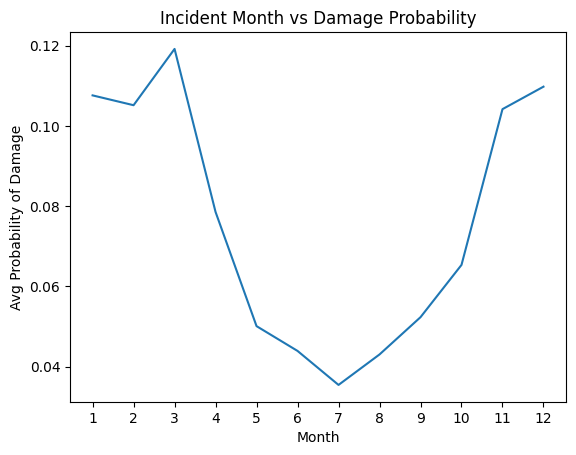

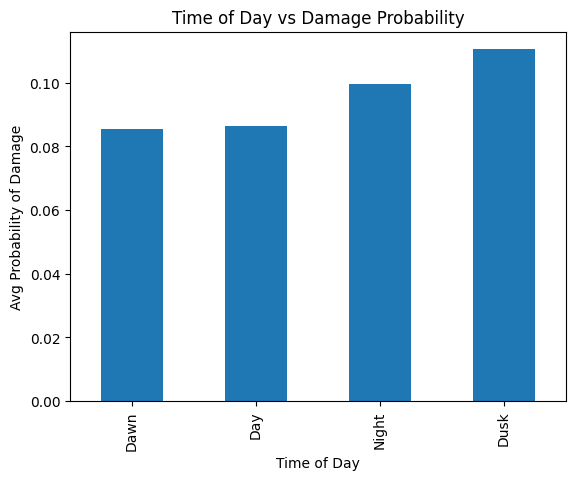

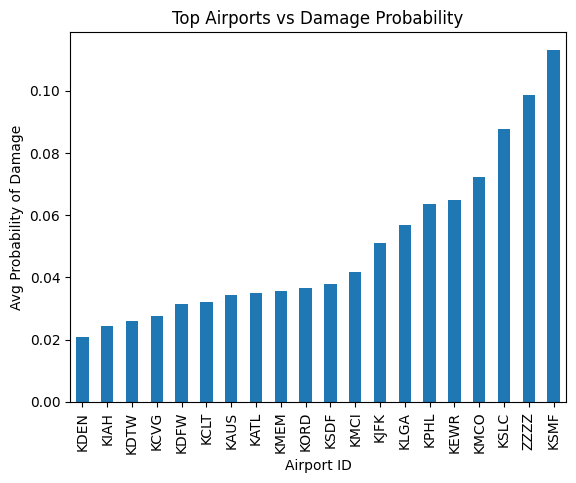

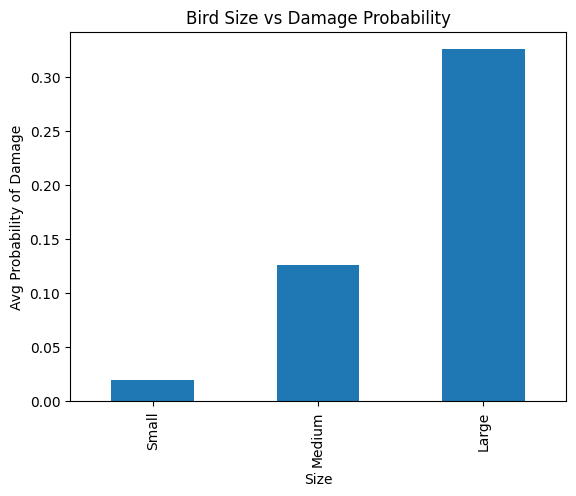

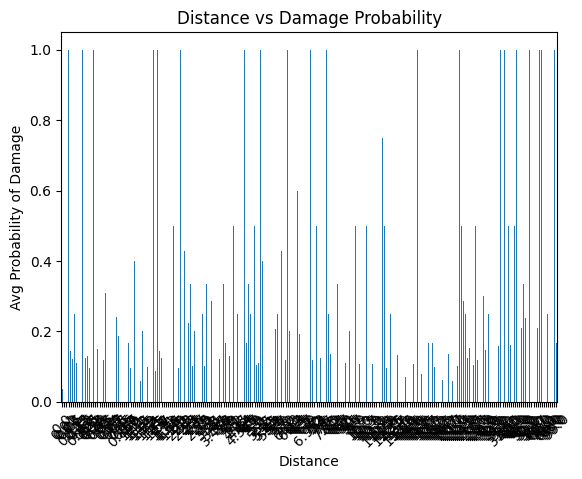

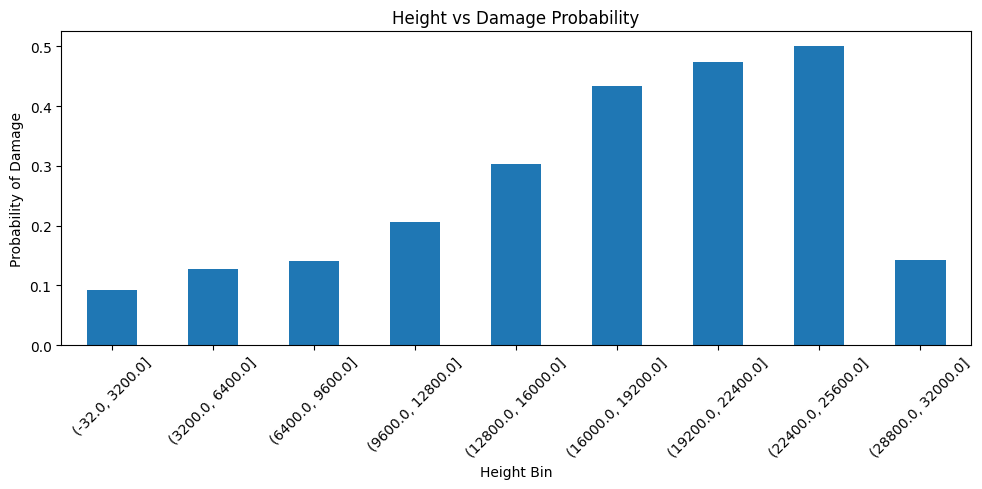

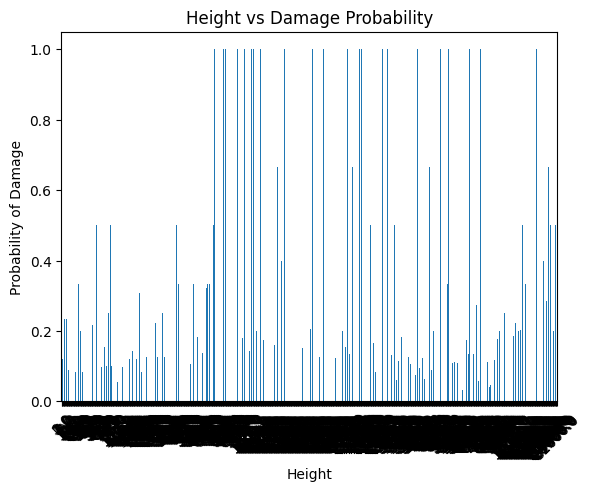

C:\Users\carso\AppData\Local\Temp\ipykernel_25968\3935924885.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = speed_df.groupby("SPEED_BIN")


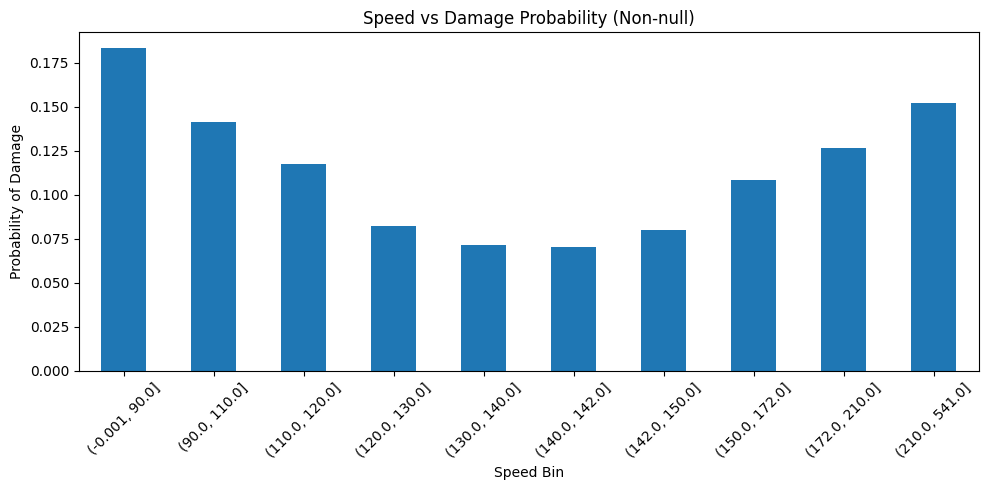

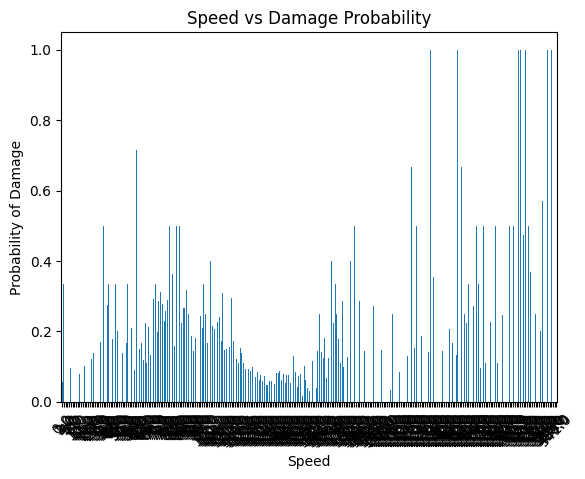

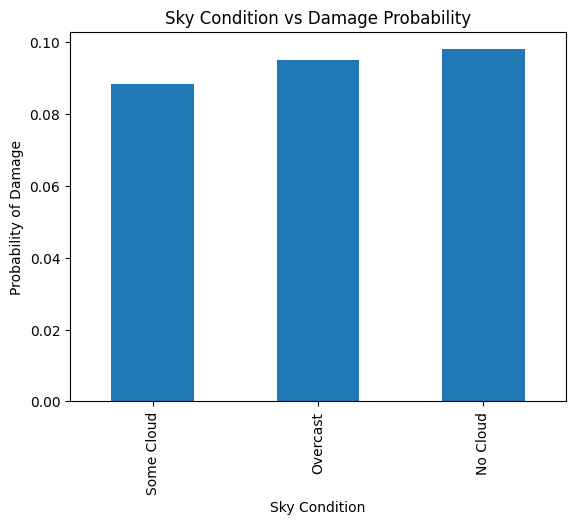

In [5]:
# Plotting "INCIDENT_MONTH" against "INDICATED_DAMAGE"
month_prob = train_data.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].mean()
plt.figure()
plt.plot(month_prob.index, month_prob.values)
plt.title("Incident Month vs Damage Probability")
plt.xlabel("Month")
plt.ylabel("Avg Probability of Damage")
plt.xticks(month_prob.index)
plt.show()


# Plotting "TIME_OF_DAY" against "INDICATED_DAMAGE"
time_prob = train_data.groupby("TIME_OF_DAY")["INDICATED_DAMAGE"].mean()
plt.figure()
time_prob.sort_values().plot(kind="bar")
plt.title("Time of Day vs Damage Probability")
plt.xlabel("Time of Day")
plt.ylabel("Avg Probability of Damage")
plt.show()


# Plotting the top 20 "AIRPORT_ID" against "INDICATED_DAMAGE"
top_airports = train_data["AIRPORT_ID"].value_counts().head(20).index
airport_prob = (
    train_data[train_data["AIRPORT_ID"].isin(top_airports)]
    .groupby("AIRPORT_ID")["INDICATED_DAMAGE"]
    .mean()
)
plt.figure()
airport_prob.sort_values().plot(kind="bar")
plt.title("Top Airports vs Damage Probability")
plt.xlabel("Airport ID")
plt.ylabel("Avg Probability of Damage")
plt.show()


# Plotting "SIZE" against "INDICATED_DAMAGE"
size_prob = train_data.groupby("SIZE")["INDICATED_DAMAGE"].mean()
plt.figure()
size_prob.sort_values().plot(kind="bar")
plt.title("Bird Size vs Damage Probability")
plt.xlabel("Size")
plt.ylabel("Avg Probability of Damage")
plt.show()


# Plotting "DISTANCE" against "INDICATED_DAMAGE"
dist_prob = train_data.groupby("DISTANCE")["INDICATED_DAMAGE"].mean()
plt.figure()
dist_prob.plot(kind="bar")
plt.title("Distance vs Damage Probability")
plt.xlabel("Distance")
plt.ylabel("Avg Probability of Damage")
plt.xticks(rotation=45)
plt.show()


# Plotting non-null "HEIGHT" records against "INDICATED_DAMAGE"
height_df = train_data[["HEIGHT", "INDICATED_DAMAGE"]].copy()
height_df = height_df.dropna(subset=["HEIGHT"])

# Bin height
height_df["HEIGHT_BIN"] = pd.cut(height_df["HEIGHT"], bins=10)
height_prob = height_df.groupby("HEIGHT_BIN", observed=True)["INDICATED_DAMAGE"].mean()

plt.figure(figsize=(10, 5))
height_prob.plot(kind="bar")
plt.title("Height vs Damage Probability")
plt.xlabel("Height Bin")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plotting "HEIGHT" against "INDICATED_DAMAGE"
height_prob = train_data.groupby("HEIGHT")["INDICATED_DAMAGE"].mean()
plt.figure()
height_prob.plot(kind="bar")
plt.title("Height vs Damage Probability")
plt.xlabel("Height")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.show()


# Plotting non-null "SPEED" against "INDICATED_DAMAGE"
speed_df = train_data[["SPEED", "INDICATED_DAMAGE"]].copy()
speed_df = speed_df.dropna(subset=["SPEED"])

# Bin speeds
speed_df["SPEED_BIN"] = pd.qcut(speed_df["SPEED"], q=10, duplicates="drop")

# Compute probability + counts
grouped = speed_df.groupby("SPEED_BIN")
speed_prob = grouped["INDICATED_DAMAGE"].mean()
counts = grouped["INDICATED_DAMAGE"].count()

plt.figure(figsize=(10, 5))
speed_prob.plot(kind="bar")
plt.title("Speed vs Damage Probability (Non-null)")
plt.xlabel("Speed Bin")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plotting "SPEED" against "INDICATED_DAMAGE"
speed_prob = train_data.groupby("SPEED")["INDICATED_DAMAGE"].mean()
plt.figure()
speed_prob.plot(kind="bar")
plt.title("Speed vs Damage Probability")
plt.xlabel("Speed")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.show()


# Plotting "SKY" against "INDICATED_DAMAGE"
sky_prob = train_data.groupby("SKY")["INDICATED_DAMAGE"].mean()
plt.figure()
sky_prob.sort_values().plot(kind="bar")
plt.title("Sky Condition vs Damage Probability")
plt.xlabel("Sky Condition")
plt.ylabel("Probability of Damage")
plt.show()


## Drop Columns with Excessive Missing Values

Our first cleaning decision is to remove columns that are missing at least 50% of their values. When a feature is mostly empty, it is hard to use reliably without making assumptions during imputation.

We chose this threshold as a way to reduce noise and simplify the feature space. Rather than forcing imputation on extremely sparse columns, we keep the features that contain enough information to be useful.

Dropping a sparse column may remove some signal, but keeping too many incomplete variables can also hurt model quality and make the pipeline harder to interpret.

In [6]:
def get_sparse_cols(df):
    sparse_cols = []

    for col in df.columns:
        if df[col].isnull().sum() >= len(df) / 2:
            if col != "SPEED":
                sparse_cols.append(col)

    return sparse_cols

In [7]:
def drop_sparse_cols(df, sparse_cols):
    df = df.copy()

    # For each column, drop the column if it has 50% or more of its data missing
    print("Before:", len(df.columns))

    for col in sparse_cols:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)
            print("Dropped:", col)

    print("After:", len(df.columns))
    return df

In [8]:
sparse_cols = get_sparse_cols(X_train_raw)

print("Dropping sparse columns for train data")
X_train_raw = drop_sparse_cols(X_train_raw, sparse_cols)
X_val_raw = drop_sparse_cols(X_val_raw, sparse_cols)

print("\nDropping sparse columns for test data")
test_data = drop_sparse_cols(test_data, sparse_cols)

Dropping sparse columns for train data
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43

Dropping sparse columns for test data
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43


## Remove Redundant or Overlapping Features

Next, we remove several columns that appear to overlap heavily with other features we plan to keep. For example, some text columns have other equivalents, and some location fields overlap with latitude and longitude.

Such as:
- `AIRPORT` overlaps with `AIRPORT_ID` / coordinates
- `OPERATOR` overlaps with `OPID`
- `SPECIES` overlaps with `SPECIES_ID`

Our goal is to reduce redundancy and avoid giving the model multiple versions of the same information.

In [9]:
def drop_redundant_cols(df):
    df = df.copy()

    print("Before:", len(df.columns))

    for col in ["AIRPORT", "OPERATOR", "SPECIES"]:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)

    print("After:", len(df.columns))
    return df

In [10]:
print("Dropping redundant columns for train data")
X_train_raw = drop_redundant_cols(X_train_raw)
X_val_raw = drop_redundant_cols(X_val_raw)

print("\nDropping redundant columns for test data")
test_data = drop_redundant_cols(test_data)

Dropping redundant columns for train data
Before: 43
After: 40
Before: 43
After: 40

Dropping redundant columns for test data
Before: 43
After: 40


## Inspecting and Dropping Columns

We found that several of the columns were largely composed of administrative metadata, text, or redundant identifiers with limited predictive value. For example, fields such as `REMARKS` and `COMMENTS` contained hundreds of thousands of unique text entries, which would require extensive natural language processing to be usable. Similarly, variables like `REG` and `INCIDENT_DATE` were overly granular and risked causing the model to overfit to specific cases rather than learning broader patterns. We also observed that technical fields such as `AMA` and `AMO` had high levels of missing data and substantial overlap with other aircraft related variables. As a result, we chose to remove these columns to simplify the feature set and concentrate the model on more relevant physical and geographic predictors of strike outcomes.

In [11]:
def inspect_specific_cols(df, cols):
    present_cols = [col for col in cols if col in df.columns]

    for col in present_cols:
        unique_count = df[col].nunique()
        null_count = df[col].isna().sum()
        null_percent = (null_count / len(df)) * 100
        
        print("\nChecking column:", col)
        print("Missing:", round(null_percent, 2), "%")
        print("Unique entries:", unique_count)
    
    display(df[cols].head(5))

In [12]:
cols = ["REMARKS", "REMAINS_SENT", "COMMENTS", "SOURCE", "PERSON", "LUPDATE", "TRANSFER", "NUM_STRUCK", "FAAREGION", "INCIDENT_DATE",
        "REG", "ENG_1_POS", "ENG_2_POS", "AIRCRAFT", "AMA", "AMO", "EMA", "EMO", "AC_CLASS"]

inspect_specific_cols(train_data, cols)


Checking column: REMARKS
Missing: 11.49 %
Unique entries: 250606

Checking column: REMAINS_SENT
Missing: 0.0 %
Unique entries: 2

Checking column: COMMENTS
Missing: 33.56 %
Unique entries: 189593

Checking column: SOURCE
Missing: 0.0 %
Unique entries: 16

Checking column: PERSON
Missing: 6.17 %
Unique entries: 6

Checking column: LUPDATE
Missing: 0.0 %
Unique entries: 4720

Checking column: TRANSFER
Missing: 0.0 %
Unique entries: 1

Checking column: NUM_STRUCK
Missing: 0.21 %
Unique entries: 4

Checking column: FAAREGION
Missing: 13.26 %
Unique entries: 10

Checking column: INCIDENT_DATE
Missing: 0.0 %
Unique entries: 13113

Checking column: REG
Missing: 38.74 %
Unique entries: 44092

Checking column: ENG_1_POS
Missing: 28.56 %
Unique entries: 7

Checking column: ENG_2_POS
Missing: 33.37 %
Unique entries: 7

Checking column: AIRCRAFT
Missing: 28.3 %
Unique entries: 613

Checking column: AMA
Missing: 28.94 %
Unique entries: 93

Checking column: AMO
Missing: 38.03 %
Unique entries: 61



,REMARKS,REMAINS_SENT,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,NUM_STRUCK,FAAREGION,INCIDENT_DATE,REG,ENG_1_POS,ENG_2_POS,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS
0,NO SIGN OF BIRD ON A/C.,0,NaN,FAA Form 5200-7,Pilot,4/3/23,0,10-Feb,ASO,12/13/93,N892AA,5.0,6.0,B-727-200,148,11,34.0,10.0,A
1,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,1,FGN,2/1/10,N608FE,1.0,6.0,MD-11,583,39,22.0,7.0,A
2,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1,ASO,5/9/12,N141UP,1.0,1.0,A-300,04A,1,34.0,46.0,A
3,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,0,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,10-Feb,AWP,10/8/02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TIME 0824 LCL.,0,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,1,AWP,2/3/97,NaN,1.0,1.0,B-737-200,148,13,34.0,10.0,A


## Our reasons

These decisions were made to keep the feature set interpretable and to reduce noise before modeling.

`REMARKS`, `COMMENTS`: 
Additional notes on the incident that would be difficult to quantify within a ML model

`REMAINS_SENT`, `SOURCE`, `PERSON`, `LUPDATE`, `TRANSFER`, `REG`:
Not very predictive of if there was damage to the aircraft

`NUM_STRUCK`:
89% of the data was the same, and almost all of the rest was corrupted

`FAAREGION`:
We decided to use LONG and LAT instead

`INCIDENT_DATE`: 
This is less relevant than other time values that we decided to keep

`ENG_1_POS`, `ENG_2_POS`, `AIRCRAFT`, `AMA`, `AMO`, `EMA`, `EMO`:
Dropped due to a combination of many missing values and a difficulty to generalize this across different aircrafts

`AC_CLASS`: 
70% of the data is an aircraft, 2 records total are helicopters, rest is unknown. So this is not very helpful

In [13]:
def drop_selected_cols(df, cols):
    df = df.copy()
    
    print("Before:", len(df.columns))

    for col in cols:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)

    print("After:", len(df.columns))
    return df

In [14]:
print("Dropping selected columns for train data")
X_train_raw = drop_selected_cols(X_train_raw, cols)
X_val_raw = drop_selected_cols(X_val_raw, cols)

print("\nDropping selected columns for test data")
test_data = drop_selected_cols(test_data, cols)

Dropping selected columns for train data
Before: 40
After: 21
Before: 40
After: 21

Dropping selected columns for test data
Before: 40
After: 21


## Re-check missing values after removing columns

After dropping the noisiest/sparsest columns, we inspected missing values again. Since the remaining missing values are more manageable, we do imputation based on the type of variable and the context of the data.

In [15]:
print(X_train_raw.isnull().sum()[X_train_raw.isnull().sum() > 0] / len(X_train_raw) * 100)

TIME               43.027240
TIME_OF_DAY        43.588805
LATITUDE           13.249261
LONGITUDE          13.250482
RUNWAY             24.629083
STATE              13.249261
OPID               28.226758
AC_MASS            28.466440
TYPE_ENG           28.576312
NUM_ENGS           28.549861
PHASE_OF_FLIGHT    39.365269
SPEED              69.071221
DISTANCE           33.644635
SIZE               10.897608
dtype: float64


## Cleaning and Imputing Features

Instead of applying one generic fill strategy to everything, we use more targeted methods based on the meaning of each variable.

We did the following:
- correct formatting issues in latitude and longitude
- fill missing geographic values using airport and state information
- convert time into a numeric hour feature and impute missing values using time of day groups
- fill missing distance values using phase of flight
- prepare these features so they can be used more effectively during modeling

In [16]:
def inspect_format(df):
    # Identify rows containing a comma in the LATITUDE column
    has_comma = df["LATITUDE"].str.contains(",", na=False)
    rows = df[has_comma]
    
    num = len(rows)
    if num > 0:
        print("Num rows with combined lat/long strings:", num)
        display(rows[["LATITUDE", "LONGITUDE"]].head(5))
    else:
        print("No combined strings detected in this dataset.")

inspect_format(train_data)

Num rows with combined lat/long strings: 7


,LATITUDE,LONGITUDE
933,"40.1821881,-79","40.1821881,-79"
13996,"37.0747673,-77",-77.9565984
19662,"70.3442778,-15",-150.94475
25674,"37.0747673,-77",-77.9565984
82745,"42.6907171,-88","42.6907171,-88"


In [17]:
def fix_format(df):
    df = df.copy()
    comma_errors = df["LATITUDE"].str.contains(",", na=False)
    values = df.loc[comma_errors, "LATITUDE"].str.split(",", expand=True)

    # Fix the comma errors
    df.loc[comma_errors, "LATITUDE"] = values[0]
    df.loc[comma_errors, "LONGITUDE"] = values[1]

    return df

In [18]:
def inspect_coords(df):
    df = df.copy()
    df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
    df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")
    
    missing = df[["LATITUDE", "LONGITUDE"]].isna().any(axis=1)
    rows = df[missing].copy()
    
    num_rows = len(rows)
    if num_rows > 0:
        print("Num rows missing coordinates:", num_rows)
    else:
        print("No missing coordinates found")

inspect_coords(train_data)

Num rows missing coordinates: 40755


In [19]:
def fill_lat_long(df, fit=True, stats=None):
    df = df.copy()

    # Make LAT and LONG numeric floats
    df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
    df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")

    # Only compute stats if we're fitting the data, otherwise we should already have them
    if fit:
        stats = {}

        for col in ["LATITUDE", "LONGITUDE"]:
            airport_median = df.groupby("AIRPORT_ID")[col].median()
            state_median = df.groupby("STATE")[col].median()
            global_median = df[col].median()
            stats[col] = {"airport": airport_median, "state": state_median, "global": global_median}

    # Fill missing values with the median for that airport, state, global
    for col in ["LATITUDE", "LONGITUDE"]:
        df[col] = df[col].fillna(df["AIRPORT_ID"].map(stats[col]["airport"]))
        df[col] = df[col].fillna(df["STATE"].map(stats[col]["state"]))
        df[col] = df[col].fillna(stats[col]["global"])

    df.drop("AIRPORT_ID", inplace=True, axis=1, errors="ignore")
    df.drop("STATE", inplace=True, axis=1, errors="ignore")

    if fit:
        return df, stats
    
    return df

In [20]:
def inspect_time(df):
    cols_to_show = ['TIME']
    if 'TIME_OF_DAY' in df.columns:
        cols_to_show.append('TIME_OF_DAY')
        
    sample_data = pd.concat([df.dropna(subset=['TIME']).head(3), df[df['TIME'].isna()].head(3)])
    display(sample_data[cols_to_show])

inspect_time(train_data)

,TIME,TIME_OF_DAY
1,5:00,Night
2,2:00,Night
5,8:58,Day
0,NaN,Day
3,NaN,NaN
4,NaN,Dawn


Based on the raw data, we realized the `TIME` column is too granular for finding patterns, so we round each timestamp to the nearest numeric Hour to help the models generalize across different risk periods. Since many rows are missing specific times but still provide a TIME_OF_DAY label like "Night" or "Dawn," we use hierarchical imputation to fill those gaps with the median hour of that specific period.

In [21]:
def clean_time(df, fit=True, stats=None):
    df = df.copy()

    # Extracting out the hour value from the time column
    df["TIME"] = pd.to_datetime(df["TIME"], format="%H:%M", errors="coerce").dt.round("h").dt.hour

    # Only compute stats if we're fitting the data, otherwise we should already have them
    if fit:
        stats = {}
        stats["time_by_period"] = df.groupby("TIME_OF_DAY")["TIME"].median()
        stats["global_time"] = df["TIME"].median()

    # Filling missing TIME values with the median value of it's TIME_OF_DAY
    df["TIME"] = df["TIME"].fillna(df["TIME_OF_DAY"].map(stats["time_by_period"]))

    # Filling rest of missing TIME values with median time
    df["TIME"] = df["TIME"].fillna(stats["global_time"])

    # Drop TIME_OF_DAY column  
    df.drop("TIME_OF_DAY", inplace=True, axis=1, errors="ignore")

    if fit:
        return df, stats
    
    return df

train_data, time_stats = clean_time(train_data, fit=True)
inspect_time(train_data)

,TIME
0,12.0
1,5.0
2,2.0


In [22]:
def inspect_distance(df):
    # Identify rows with valid distance and rows missing distance
    sample_data = pd.concat([df.dropna(subset=['DISTANCE']).head(3), df[df['DISTANCE'].isna() & df['PHASE_OF_FLIGHT'].notna()].head(3)])
    count = df['DISTANCE'].isna().sum()
    print("Num rows missing DISTANCE:", count)
    display(sample_data[['DISTANCE', 'PHASE_OF_FLIGHT']])

inspect_distance(train_data)

Num rows missing DISTANCE: 103303


,DISTANCE,PHASE_OF_FLIGHT
1,0.0,Approach
2,8.0,Approach
3,0.0,NaN
0,NaN,Approach
17,NaN,Climb
21,NaN,Approach


In [23]:
def clean_distance(df, fit=True, stats=None):
    df = df.copy()

    if fit:
        stats = {}
        stats["phase"] = df.groupby("PHASE_OF_FLIGHT")["DISTANCE"].median()
        stats["global"] = df["DISTANCE"].median()

    # Use PHASE_OF_FLIGHT to fill in nans for DISTANCE
    df["DISTANCE"] = df["DISTANCE"].fillna(df["PHASE_OF_FLIGHT"].map(stats["phase"]))

    # Just use median DISTANCE for nans if PHASE_OF_FLIGHT is also missing for the data point
    df["DISTANCE"] = df["DISTANCE"].fillna(stats["global"])

    if fit:
        return df, stats
    
    return df

train_data, distance_stats = clean_distance(train_data, fit=True)
inspect_distance(train_data)

Num rows missing DISTANCE: 0


,DISTANCE,PHASE_OF_FLIGHT
0,1.0,Approach
1,0.0,Approach
2,8.0,Approach


In [24]:
def inspect_speed(df):
    # Identify rows with valid speed and rows where speed is missing
    sample_data = pd.concat([df.dropna(subset=['SPEED']).head(3), df[df['SPEED'].isna() & df['PHASE_OF_FLIGHT'].notna()].head(3)])
    count = df['SPEED'].isna().sum()
    print("Num rows missing SPEED:", count)
    display(sample_data[['SPEED', 'PHASE_OF_FLIGHT']])

inspect_speed(train_data)

Num rows missing SPEED: 212076


,SPEED,PHASE_OF_FLIGHT
0,145.0,Approach
2,240.0,Approach
4,135.0,Landing Roll
1,NaN,Approach
6,NaN,Take-off Run
7,NaN,Take-off Run


In [25]:
def clean_speed(df, fit=True, stats=None):
    df = df.copy()

    df["SPEED_MISSING"] = df["SPEED"].isnull().astype(int)

    if fit:
        stats = {}
        stats["phase"] = df.groupby("PHASE_OF_FLIGHT")["SPEED"].median()
        stats["global"] = df["SPEED"].median()

    # Use PHASE_OF_FLIGHT to fill in nans for SPEED
    df["SPEED"] = df["SPEED"].fillna(df["PHASE_OF_FLIGHT"].map(stats["phase"]))

    # Just use median SPEED for nans if PHASE_OF_FLIGHT is also missing for the data point
    df["SPEED"] = df["SPEED"].fillna(stats["global"])

    if fit:
        return df, stats

    return df

train_data, speed_stats = clean_speed(train_data, fit=True)
inspect_speed(train_data)

Num rows missing SPEED: 0


,SPEED,PHASE_OF_FLIGHT
0,145.0,Approach
1,140.0,Approach
2,240.0,Approach


In [26]:
def clean_features(df, fit=True, stats=None):
    df = df.copy()
    
    print("Before:", len(df.columns))

    # Fix formatting
    df = fix_format(df)

    if fit:
        stats = {}
        df, stats["geo"] = fill_lat_long(df, fit=True)
        df, stats["time"] = clean_time(df, fit=True)
        df, stats["distance"] = clean_distance(df, fit=True)
        df, stats["speed"] = clean_speed(df, fit=True)


    else:
        df = fill_lat_long(df, fit=False, stats=stats["geo"])
        df = clean_time(df, fit=False, stats=stats["time"])
        df = clean_distance(df, fit=False, stats=stats["distance"])
        df = clean_speed(df, fit=False, stats=stats["speed"])

    print("After:", len(df.columns))
    print(df.isnull().sum() / len(df) * 100)

    if fit:
        return df, stats
    
    return df

In [27]:
print("Cleaning features for train data")
X_train_clean, feature_stats = clean_features(X_train_raw, fit=True)
X_val_clean = clean_features(X_val_raw, fit=False, stats=feature_stats)

print("\nCleaning features for test data")
test_data = clean_features(test_data, fit=False, stats=feature_stats)

Cleaning features for train data
Before: 21
After: 19
INDEX_NR                 0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
LATITUDE                 0.000000
LONGITUDE                0.000000
RUNWAY                  24.629083
OPID                    28.226758
AC_MASS                 28.466440
TYPE_ENG                28.576312
NUM_ENGS                28.549861
PHASE_OF_FLIGHT         39.365269
SPEED                    0.000000
DISTANCE                 0.000000
SPECIES_ID               0.000000
OUT_OF_RANGE_SPECIES     0.000000
REMAINS_COLLECTED        0.000000
SIZE                    10.897608
SPEED_MISSING            0.000000
dtype: float64
Before: 21
After: 19
INDEX_NR                 0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
LATITUDE                 0.000000
LONGITUDE                0.000000
RUNWAY                  24.516570
OPID                    28

Filling remaining missing values

In [28]:
def inspect_cols(df):
    columns_with_nans = df.columns[df.isna().any()].tolist()
    
    if not columns_with_nans:
        print("No missing values detected in the dataset")
        return
    
    print("Total missing values:", df.isnull().sum().sum())
    print("Columns with missing values:")
    print(columns_with_nans)
    
    missing = df[df[columns_with_nans].isna().any(axis=1)].head(5)
    
    print("\nRaw data with missing values:")
    display(missing[columns_with_nans])
    
    print("\nMissing Value Count per Column:")
    print(df[columns_with_nans].isna().sum())

inspect_cols(train_data)

Total missing values: 4581934
Columns with missing values:
['AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'REMARKS', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'COMMENTS', 'PERSON']

Raw data with missing values:


,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,...,PRECIPITATION,BIRD_BAND_NUMBER,REMARKS,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,PERSON
0,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,...,NaN,NaN,NO SIGN OF BIRD ON A/C.,No,10-Feb,10-Feb,Small,NaN,NaN,Pilot
1,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,...,NaN,NaN,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,NaN,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,Air Transport Operations
2,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,...,NaN,NaN,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Operations
3,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,NaN,NaN,NaN,...,NaN,NaN,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,NaN,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,Carcass Found
4,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,...,NaN,NaN,TIME 0824 LCL.,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,NaN



Missing Value Count per Column:
AIRPORT              40684
LATITUDE             40744
LONGITUDE            40747
RUNWAY               75586
STATE                40744
FAAREGION            40744
LOCATION            267965
OPID                 86692
OPERATOR             86692
REG                 118999
FLT                 161442
AIRCRAFT             86942
AMA                  88896
AMO                 116813
EMA                 102421
EMO                 113176
AC_CLASS             87315
AC_MASS              87446
TYPE_ENG             87786
NUM_ENGS             87697
ENG_1_POS            87717
ENG_2_POS           102509
ENG_3_POS           294822
ENG_4_POS           303909
PHASE_OF_FLIGHT     120970
HEIGHT              154197
SKY                 162825
PRECIPITATION       295966
BIRD_BAND_NUMBER    306465
REMARKS              35305
WARNED              191135
NUM_SEEN            208546
NUM_STRUCK             647
SIZE                 33507
ENROUTE_STATE       301832
COMMENTS            10

Using inspect_cols, we observed that the dataset contained a substantial number of missing values spread across many columns, with some features like `PRECIPITATION`, `BIRD_BAND_NUMBER`, and `ENROUTE_STATE` missing in more than 95% of rows. Other important fields such as `NUM_ENGS`, `AC_MASS`, and `TYPE_ENG` had moderate levels of missingness but were still valuable for modeling. 

Based on this, we applied cleaning in fill_missing_values by dropping or simplifying columns that were either redundant or too sparse, converting certain missingness into meaningful signals, reduced high-cardinality categorical noise, and filled key numerical and categorical features using training-set statistics (median or mode).

In [29]:
def fill_missing_values(df, fit=True, stats=None, top_ops=None):
    df = df.copy()

    print("Before:", len(df.columns))

    # Convert runway to is or isn't airborne
    df["AIRBORNE"] = df["RUNWAY"].isnull().astype(int)
    df.drop("RUNWAY", inplace=True, axis=1, errors="ignore")

    # Fill in missing SIZE with "UNK"
    df["SIZE"] = df["SIZE"].fillna("UNK")

    # Drop SPECIES_ID since it is mostly null and we have the more useful SPECIES column
    df.drop("SPECIES_ID", inplace=True, axis=1, errors="ignore")

    if fit:
        # Get the top 10 most common OPERATORs to reduce cardinality of the OPID column, and save stats for filling missing later
        if top_ops is None:
            top_ops = df["OPID"].value_counts().nlargest(10).index

        # Stats for filling missing NUM_ENGS, AC_MASS, and TYPE_ENG values later
        stats = {"num_engs_median": df["NUM_ENGS"].median(), "ac_mass_median": df["AC_MASS"].median(), "type_eng_mode": df["TYPE_ENG"].mode()[0]}

    # Reduce cardinality of OPID by only keeping the top 10 most common OPERATORs and filling the rest with "UNK"
    df["OPID"] = df["OPID"].where(df["OPID"].isin(top_ops), "UNK")

    # Add missing values for PHASE_OF_FLIGHT
    df["PHASE_OF_FLIGHT"] = df["PHASE_OF_FLIGHT"].fillna("MISSING")

    # Fill in missing values using TRAIN stats
    df["NUM_ENGS"] = df["NUM_ENGS"].fillna(stats["num_engs_median"])
    df["AC_MASS"] = df["AC_MASS"].fillna(stats["ac_mass_median"])
    df["TYPE_ENG"] = df["TYPE_ENG"].fillna(stats["type_eng_mode"])

    print("After:", len(df.columns))
    print(df.isnull().sum() / len(df) * 100)

    if fit:
        return df, top_ops, stats
    return df

train_data, top_ops, fill_stats = fill_missing_values(train_data, fit=True)
inspect_cols(train_data)

Before: 55
After: 54
INDEX_NR                 0.000000
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
AIRPORT_ID               0.000000
AIRPORT                 13.244438
LATITUDE                13.263971
LONGITUDE               13.264947
STATE                   13.263971
FAAREGION               13.263971
LOCATION                87.234437
OPID                     0.000000
OPERATOR                28.222073
REG                     38.739428
FLT                     52.556498
AIRCRAFT                28.303459
AMA                     28.939572
AMO                     38.027788
EMA                     33.342557
EMO                     36.843784
AC_CLASS                28.424887
AC_MASS                  0.000000
TYPE_ENG                 0.000000
NUM_ENGS                 0.000000
ENG_1_POS               28.555756
ENG_2_POS               33.371205
ENG_3_POS               95.977577
ENG_4_POS               98.

,AIRPORT,LATITUDE,LONGITUDE,STATE,FAAREGION,LOCATION,OPERATOR,REG,FLT,AIRCRAFT,...,SKY,PRECIPITATION,BIRD_BAND_NUMBER,REMARKS,WARNED,NUM_SEEN,NUM_STRUCK,ENROUTE_STATE,COMMENTS,PERSON
0,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,PR,ASO,NaN,AMERICAN AIRLINES,N892AA,NaN,B-727-200,...,Some Cloud,NaN,NaN,NO SIGN OF BIRD ON A/C.,No,10-Feb,10-Feb,NaN,NaN,Pilot
1,KUALA LUMPUR INTL,2.745578,101.709917,FN,FGN,NaN,FEDEX EXPRESS,N608FE,5293,MD-11,...,NaN,NaN,NaN,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,NaN,NaN,1,NaN,2010-5-18-53374 /Legacy Record 300758/,Air Transport Operations
2,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,KY,ASO,NaN,UPS AIRLINES,N141UP,907,A-300,...,NaN,NaN,NaN,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",No,NaN,1,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Operations
3,LOS ANGELES INTL,33.94254,-118.40807,CA,AWP,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,NaN,NaN,10-Feb,NaN,2002-10-8-111929 /Legacy Record 216397/,Carcass Found
4,LIHUE ARPT,21.97598,-159.33896,HI,AWP,NaN,ALOHA AIRLINES,NaN,NaN,B-737-200,...,Some Cloud,NaN,NaN,TIME 0824 LCL.,No,1,1,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,NaN



Missing Value Count per Column:
AIRPORT              40684
LATITUDE             40744
LONGITUDE            40747
STATE                40744
FAAREGION            40744
LOCATION            267965
OPERATOR             86692
REG                 118999
FLT                 161442
AIRCRAFT             86942
AMA                  88896
AMO                 116813
EMA                 102421
EMO                 113176
AC_CLASS             87315
ENG_1_POS            87717
ENG_2_POS           102509
ENG_3_POS           294822
ENG_4_POS           303909
HEIGHT              154197
SKY                 162825
PRECIPITATION       295966
BIRD_BAND_NUMBER    306465
REMARKS              35305
WARNED              191135
NUM_SEEN            208546
NUM_STRUCK             647
ENROUTE_STATE       301832
COMMENTS            103083
PERSON               18968
dtype: int64


In [30]:
print("Filling missing values for train data")
X_train_filled, top_ops, fill_stats = fill_missing_values(X_train_clean, fit=True)
X_val_filled = fill_missing_values(X_val_clean, fit=False, stats=fill_stats, top_ops=top_ops)

print("\nFilling missing values for test data")
test_data = fill_missing_values(test_data, fit=False, stats=fill_stats, top_ops=top_ops)

Filling missing values for train data
Before: 19
After: 18
INDEX_NR                0.0
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
TIME                    0.0
LATITUDE                0.0
LONGITUDE               0.0
OPID                    0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
PHASE_OF_FLIGHT         0.0
SPEED                   0.0
DISTANCE                0.0
OUT_OF_RANGE_SPECIES    0.0
REMAINS_COLLECTED       0.0
SIZE                    0.0
SPEED_MISSING           0.0
AIRBORNE                0.0
dtype: float64
Before: 19
After: 18
INDEX_NR                0.0
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
TIME                    0.0
LATITUDE                0.0
LONGITUDE               0.0
OPID                    0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
PHASE_OF_FLIGHT         0.0
SPEED                   0.0
DISTANCE                0.0
OUT_OF_RANGE_SPECIES    0.0
REMAINS_C

## Identify Categorical Features

Before encoding, we identify which remaining columns should be treated as categorical. This matters because machine learning models generally require numeric input, but not all variables should be converted the same way.

In [31]:
def identify_categorical_cols(df):
    categorical_cols = []
    numeric_cols = []

    for col in df.columns:
        # Try converting column to numeric
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # If any portion becomes NaN, it's categorical
        num_na = converted.isnull().sum()
        
        if num_na > 1:
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)

    print("Categorical Columns:")
    print(categorical_cols)

    print("\nNumeric Columns:")
    print(numeric_cols)

    print("\nTypes of the column data:")
    print(df.dtypes)

    return categorical_cols

In [32]:
print("Identifying categorical columns from train data")
categorical_cols = identify_categorical_cols(X_train_filled)

Identifying categorical columns from train data
Categorical Columns:
['OPID', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SIZE']

Numeric Columns:
['INDEX_NR', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'LATITUDE', 'LONGITUDE', 'AC_MASS', 'NUM_ENGS', 'SPEED', 'DISTANCE', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'SPEED_MISSING', 'AIRBORNE']

Types of the column data:
INDEX_NR                  int64
INCIDENT_MONTH            int64
INCIDENT_YEAR             int64
TIME                    float64
LATITUDE                float64
LONGITUDE               float64
OPID                     object
AC_MASS                 float64
TYPE_ENG                 object
NUM_ENGS                float64
PHASE_OF_FLIGHT          object
SPEED                   float64
DISTANCE                float64
OUT_OF_RANGE_SPECIES      int64
REMAINS_COLLECTED         int64
SIZE                     object
SPEED_MISSING             int64
AIRBORNE                  int64
dtype: object


## Encoding Categorical Features

Initially, we encoded all categorical variables using **one-hot encoding**. This approach is simple and works well for models because it does not create any ordering between categories.

In [33]:
def encode_cols(df, categorical_cols, fit=True, encoders=None):
    df = df.copy()

    if "INDICATED_DAMAGE" in df.columns:
        X = df.drop("INDICATED_DAMAGE", axis=1).copy()
    else:
        X = df.copy()

    print("Number of rows and cols before encoding:", X.shape)

    if fit:
        high_card_cols = []
        low_card_cols = []

        for col in categorical_cols:
            num_unique = X[col].nunique()

            # Threshold: > 10 unique values, high cardinality
            if num_unique > 10:
                high_card_cols.append(col)
            else:
                low_card_cols.append(col)

        print("High-cardinality columns (frequency encode):", high_card_cols)
        print("Low-cardinality columns (one-hot encode):", low_card_cols)

        freq_maps = {}

        # Frequency encode for high-cardinality columns
        for col in high_card_cols:
            freq = X[col].value_counts(normalize=True)
            freq_maps[col] = freq
            X[col] = X[col].map(freq)

        # One-hot encode for low-cardinality columns
        X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=False)

        encoders = {
            "high_card_cols": high_card_cols,
            "low_card_cols": low_card_cols,
            "freq_maps": freq_maps,
            "train_cols": X_encoded.columns
        }

        print("Final shape after encoding:", X_encoded.shape)
        return X_encoded, encoders

    else:
        high_card_cols = encoders["high_card_cols"]
        low_card_cols = encoders["low_card_cols"]
        freq_maps = encoders["freq_maps"]
        train_cols = encoders["train_cols"]

        # Frequency encode using train frequencies
        for col in high_card_cols:
            X[col] = X[col].map(freq_maps[col]).fillna(0)

        # One-hot encode
        X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=False)

        # Align columns to training columns
        X_encoded = X_encoded.reindex(columns=train_cols, fill_value=0)

        print("Final shape after encoding:", X_encoded.shape)
        return X_encoded

In [34]:
print("Encoding columns for train data")
X_encoded, encoders = encode_cols(X_train_filled, categorical_cols, fit=True)
X_val_encoded = encode_cols(X_val_filled, categorical_cols, fit=False, encoders=encoders)

print("\nEncoding columns for test data")
X_test_encoded = encode_cols(test_data, categorical_cols, fit=False, encoders=encoders)

Encoding columns for train data
Number of rows and cols before encoding: (245742, 18)
High-cardinality columns (frequency encode): ['OPID', 'PHASE_OF_FLIGHT']
Low-cardinality columns (one-hot encode): ['TYPE_ENG', 'SIZE']
Final shape after encoding: (245742, 27)
Number of rows and cols before encoding: (61436, 18)
Final shape after encoding: (61436, 27)

Encoding columns for test data
Number of rows and cols before encoding: (34131, 18)
Final shape after encoding: (34131, 27)


## Modeling: Neural Nets

Our first modeling approach used a neural network to learn patterns from the processed features. After scaling the data with StandardScaler, we trained a multi-layer network with ReLU activations and dropout layers to reduce overfitting. Because the dataset is imbalanced, we incorporated class weights so the model would not bias toward the majority “no damage” class.

We evaluated performance using balanced accuracy and experimented with different probability thresholds rather than relying on the default 0.5 cutoff, allowing us to better balance false positives and false negatives. This approach served as a baseline to test how well a neural network could capture relationships in the data before moving to more specialized models.

- 128, 64, and 32 Nodes: We used a progressively smaller architecture to first capture complex feature interactions with 128 neurons, then gradually compress that info into more compact representations.

- Dropout(0.3): We applied a 30% dropout rate after the larger layers to reduce overfitting. By randomly deactivating neurons during training, the model is encouraged to learn more robust/ redundant representations rather than depending too heavily on a small set of features.

- 20 Epochs: We trained the model for 20 epochs, which provides enough iterations for convergence while limiting the risk of overfitting to noise in the training data.

- Sigmoid Activation: Because this is a binary classification problem, we used a sigmoid activation in the output layer to convert predictions into probabilities between 0 and 1.

- Thresholds [0.3, 0.4, 0.5, 0.6]: Since damage cases are relatively rare, the default 0.5 cutoff can be too conservative. Testing multiple thresholds allows us to better identify the threshold that maximizes balanced accuracy.

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Scale the features for the neural network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_encoded)
X_val = scaler.transform(X_val_encoded)

# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

# Compute the class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    class_weight=class_weights
)

# Predict probabilities on the validation set
val_probs = model.predict(X_val).flatten()

best_t = None
thresholds = [0.3, 0.4, 0.5, 0.6]
best_score = -1
scores = []

for t in thresholds:
    val_preds = (val_probs > t).astype(int)
    score = balanced_accuracy_score(y_val, val_preds)
    scores.append(score)

    if score > best_score:
        best_score = score
        best_t = t
        
    print(t, score)

{0: np.float64(0.5339431600903877), 1: np.float64(7.865254128792728)}
Epoch 1/20


c:\Users\carso\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4694 - precision: 0.1807 - recall: 0.7959 - val_loss: 0.4252 - val_precision: 0.2003 - val_recall: 0.7990
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4393 - precision: 0.1975 - recall: 0.7999 - val_loss: 0.4261 - val_precision: 0.2036 - val_recall: 0.7969
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4327 - precision: 0.2019 - recall: 0.8051 - val_loss: 0.4233 - val_precision: 0.2098 - val_recall: 0.7997
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4276 - precision: 0.2054 - recall: 0.8016 - val_loss: 0.3817 - val_precision: 0.2306 - val_recall: 0.7475
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4254 - precision: 0.2059 - recall: 0.8025 - val_loss: 0.4044 - val_precision: 0.2100 - val_recall: 0.7956
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4231 - precision: 0.2072 - recall: 0.8038 - val_loss: 0.4264 - val_precision: 0.2087 - val_recall: 0.8082
Epo

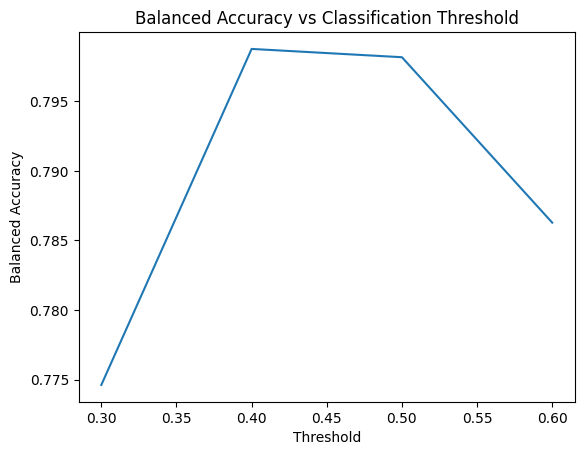

In [36]:
# Plot threshold vs balanced accuracy
plt.plot(thresholds, scores)
plt.xlabel("Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy vs Classification Threshold")
plt.show()

In [37]:
# Scale the Kaggle test data with the SAME scaler fit on X_train
X_test_scaled = scaler.transform(X_test_encoded)

# Predict probabilities on test data
test_probs = model.predict(X_test_scaled)

# Convert probabilities to 0/1 predictions
test_preds = (test_probs > best_t).astype(int)

   1/1067 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step


In [38]:
def generate_submission(test_preds):
    submission = pd.DataFrame({"INDEX_NR": test_ids,"INDICATED_DAMAGE": test_preds})
    submission.to_csv("submission.csv", index=False)
    print("Submission file created.")

In [39]:
test_preds = test_preds.flatten()
generate_submission(test_preds)

Submission file created.


## CS 363M: Machine Learning Project Part 2

Our first method worked well and got us an accuracy of around 80%. For our second approach, we attempted to clean the data differently and try gradient boosting models to see how we can improve that accuracy.

Unlike the neural network, these models can naturally handle nonlinear relationships and interactions without requiring extensive scaling or architecture tuning. We combined them within a preprocessing pipeline that included imputation and one-hot encoding, and addressed class imbalance using weighting strategies. We used stratified cross-validation to generate out-of-fold predictions and then optimized a weighted blend of the two models along with a tuned classification threshold. This approach allowed us to achieve stronger and more stable performance compared to our initial neural network attempt.

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Load the Data

We loaded the data again to start with fresh values.

In [41]:
train_data, test_data, test_ids = load_data()

print("Percent Null:", train_data.isnull().sum().sum() / (len(train_data) * len(train_data.columns)) * 100)
print(train_data.isnull().sum())

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Percent Null: 30.561646519429953
INDEX_NR                     0
INCIDENT_DATE                0
INCIDENT_MONTH               0
INCIDENT_YEAR                0
TIME                    132042
TIME_OF_DAY             133971
AIRPORT_ID                   0
AIRPORT                  40684
LATITUDE                 40744
LONGITUDE                40747
RUNWAY                   75586
STATE                    40744
FAAREGION                40744
LOCATION                267965
OPID                     86692
OPERATOR                 86692
REG                     118999
FLT                     161442
AIRCRAFT                 86942
AMA                      88896
AMO                     116813
EMA                     102421
EMO                     113176
AC_CLASS                 87315
AC_MASS                  87446
TYPE_ENG                 87786
NUM_ENGS                 87697
ENG_1_POS                87717
ENG_2_POS               102509
ENG_3_POS               294822
ENG_4_POS               303909
PHASE_

In [42]:
cols = ["REMARKS", "PERSON", "SOURCE", "BIRD_BAND_NUMBER", "REG", "FLT"]
inspect_specific_cols(train_data, cols)


Checking column: REMARKS
Missing: 11.49 %
Unique entries: 250606

Checking column: PERSON
Missing: 6.17 %
Unique entries: 6

Checking column: SOURCE
Missing: 0.0 %
Unique entries: 16

Checking column: BIRD_BAND_NUMBER
Missing: 99.77 %
Unique entries: 612

Checking column: REG
Missing: 38.74 %
Unique entries: 44092

Checking column: FLT
Missing: 52.56 %
Unique entries: 10645


,REMARKS,PERSON,SOURCE,BIRD_BAND_NUMBER,REG,FLT
0,NO SIGN OF BIRD ON A/C.,Pilot,FAA Form 5200-7,NaN,N892AA,NaN
1,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,Air Transport Operations,FAA Form 5200-7-E,NaN,N608FE,5293
2,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",Air Transport Operations,Air Transport Report,NaN,N141UP,907
3,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,Carcass Found,FAA Form 5200-7-E,NaN,NaN,NaN
4,TIME 0824 LCL.,NaN,Multiple,NaN,NaN,NaN


## Initial Data Inspection and Cleaning

In our first iteration, we used a fairly strict filtering approach, dropping any column with more than 50% missing values. While this simplified the dataset, we found that it also removed useful features like `SPEED` and `HEIGHT`, which contain important physical information for predicting damage outcomes. 

In the second iteration, we adopted a more selective strategy. Instead of removing features based primarily on missingness, we focused on eliminating variables with little predictive value, such as administrative fields (`SOURCE`, `PERSON`), text (`REMARKS`), and highly specific identifiers (`REG`, `FLT`) that could lead to overfitting. This allowed us to retain incomplete but informative numerical features, which our gradient boosting models can better leverage through imputation.

In [43]:
def drop_irrelevant_columns(data):
    data = data.copy()
    drop_cols = ["INDEX_NR", "REMARKS", "COMMENTS", "PERSON", "SOURCE", "LUPDATE", "TRANSFER", "BIRD_BAND_NUMBER", "REG", "FLT"]
    
    # Dropping columns
    for col in drop_cols:
        if col in data.columns:
            data = data.drop(columns=[col])
            
    return data

train_data = drop_irrelevant_columns(train_data)
test_data = drop_irrelevant_columns(test_data)

## Feature Engineering

### Date Features

We engineered features from the raw `INCIDENT_DATE` field to better capture seasonal patterns in wildlife activity. Instead of using the date as a string, we extracted the quarter and created binary indicators for spring, summer, fall, and winter. This allowed our gradient boosting models to incorporate seasonal effects linked to bird migration and breeding cycles, which influence both the frequency and severity of strikes. These transformed features provide more meaningful signals than the original date format by helping the model learn predictable, time-based fluctuations in risk throughout the year.

In [44]:
def inspect_date(df):
    raw_cols = ['INCIDENT_DATE', 'INCIDENT_MONTH']
    engineered_cols = ['quarter', 'is_spring', 'is_summer', 'is_fall', 'is_winter']
    
    present_raw = [col for col in raw_cols if col in df.columns]
    present_eng = [col for col in engineered_cols if col in df.columns]
    
    if present_raw:
        display(df[present_raw].head(5))
            
    if present_eng:
        display(df[present_eng].head(5))

inspect_date(train_data)

,INCIDENT_DATE,INCIDENT_MONTH
0,12/13/93,12
1,2/1/10,2
2,5/9/12,5
3,10/8/02,10
4,2/3/97,2


In [45]:
def add_date_features(data):
    if "INCIDENT_DATE" not in data.columns:
        return data

    # Convert the string column to an actual datetime type so we can extract parts from it
    dates = pd.to_datetime(data["INCIDENT_DATE"], format="%m/%d/%y", errors="coerce")
    data["quarter"] = dates.dt.quarter

    # Season flags
    data["is_spring"] = data["INCIDENT_MONTH"].isin([3, 4, 5]).astype(int)
    data["is_summer"] = data["INCIDENT_MONTH"].isin([6, 7, 8]).astype(int)
    data["is_fall"] = data["INCIDENT_MONTH"].isin([9, 10, 11]).astype(int)
    data["is_winter"] = data["INCIDENT_MONTH"].isin([12, 1, 2]).astype(int)

    data = data.drop(columns=["INCIDENT_DATE"])
    return data

train_data = add_date_features(train_data)
inspect_date(train_data)

,INCIDENT_MONTH
0,12
1,2
2,5
3,10
4,2


,quarter,is_spring,is_summer,is_fall,is_winter
0,4,0,0,0,1
1,1,0,0,0,1
2,2,1,0,0,0
3,4,0,0,1,0
4,1,0,0,0,1


### Numeric Column Conversion

Several columns that represent numeric quantities were stored as mixed-type or string columns in the raw CSV. If we leave them as strings, the model cannot use them numerically. We force each one to a proper numeric type, and any value that cannot be converted becomes `NaN`, which will be handled later by the imputer in our preprocessing pipeline.

In [46]:
def inspect_type(df):
    potential_cols = df.select_dtypes(include=['object']).columns
    numeric_cols = []

    for col in potential_cols:
        converted = pd.to_numeric(df[col], errors='coerce')
        non_null_count = df[col].notna().sum()

        if non_null_count == 0: 
            continue
        
        numeric_pct = (converted.notna().sum() / non_null_count) * 100
        
        # If over 80% of the non-null values can be converted to numeric, need to convert this column to numeric
        if numeric_pct > 80:
            numeric_cols.append(col)
            print("\nFound col:", col)
            print("Current type: object")
            print("Numeric content:", round(numeric_pct, 2), "%")

    print("\nTotal columns suggested for conversion:", len(numeric_cols))
    
    if numeric_cols:
        display(df[numeric_cols].head(5))
    
    return numeric_cols

numeric_cols = inspect_type(train_data)


Found col: LATITUDE
Current type: object
Numeric content: 100.0 %

Found col: LONGITUDE
Current type: object
Numeric content: 100.0 %

Found col: AMA
Current type: object
Numeric content: 81.46 %

Found col: AMO
Current type: object
Numeric content: 100.0 %

Found col: NUM_STRUCK
Current type: object
Numeric content: 89.15 %

Total columns suggested for conversion: 5


,LATITUDE,LONGITUDE,AMA,AMO,NUM_STRUCK
0,18.43942,-66.00183,148,11,10-Feb
1,2.745578,101.709917,583,39,1
2,38.17439,-85.736,04A,1,1
3,33.94254,-118.40807,NaN,NaN,10-Feb
4,21.97598,-159.33896,148,13,1


In [47]:
def convert_numeric_columns(data, numeric_cols):
    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")  # non-numeric values become NaN
    return data

train_data = convert_numeric_columns(train_data, numeric_cols)

### Bird Size Features

The `SIZE` column describes the bird as Small, Medium, or Large, but the raw string label is not directly usable by tree-based models in a meaningful ordinal way. We create an ordinal encoding (1, 2, 3) so the model understands that Large > Medium > Small in terms of potential impact. We also add two binary flags for large and medium birds so the model can learn non-linear relationships for specific size categories independently.

In [48]:
def inspect_size(df):
    if "SIZE" not in df.columns:
        print("Size column not found, checking for engineered size features instead")
        eng_cols = ["SIZE_ENCODED", "is_large_bird", "is_medium_bird"]
        present = [c for c in eng_cols if c in df.columns]
        if present:
            display(df[present].head(5))
        return

    # Grab a sample of each category to see the variety
    samples = []
    for size in ["Small", "Medium", "Large"]:
        match = df[df["SIZE"] == size].head(2)
        samples.append(match)
    
    samples.append(df[df["SIZE"].isna()].head(2))
    
    inspect_df = pd.concat(samples)
    
    display(inspect_df[["SIZE"]])
    
    print("\nCategory counts:")
    print(df["SIZE"].value_counts(dropna=False))

inspect_size(train_data)

,SIZE
0,Small
5,Small
1,Medium
3,Medium
2,Large
8,Large
12,NaN
17,NaN



Category counts:
SIZE
Small     189692
Medium     65601
NaN        33507
Large      18378
Name: count, dtype: int64


In [49]:
def add_size_features(data):
    if "SIZE" not in data.columns:
        return data

    # Ordinal encoding so the model knows Large > Medium > Small
    size_map = {"Small": 1, "Medium": 2, "Large": 3}
    data["SIZE_ENCODED"] = data["SIZE"].map(size_map)
    data["is_large_bird"] = (data["SIZE"] == "Large").astype(int)
    data["is_medium_bird"] = (data["SIZE"] == "Medium").astype(int)
    
    data = data.drop(columns=["SIZE"])
    return data

train_data = add_size_features(train_data)
inspect_size(train_data)

Size column not found, checking for engineered size features instead


,SIZE_ENCODED,is_large_bird,is_medium_bird
0,1.0,0,0
1,2.0,0,1
2,3.0,1,0
3,2.0,0,1
4,2.0,0,1


### Flight Phase Features

The phase of flight at the time of the strike turned out to be an important signal. Strikes during takeoff, climb, landing roll, and approach tend to be more severe because the aircraft is at lower altitudes, traveling at speeds where evasion is impossible, and the engines are under higher load. We flag each of these individually and also create a combined `is_critical_phase` feature to give the model a single high-level indicator of dangerous conditions.

In [50]:
def inspect_phase(df):
    if "PHASE_OF_FLIGHT" not in df.columns:
        print("PHASE_OF_FLIGHT column not found, checking for engineered phase features instead")
        eng_cols = ["is_takeoff", "is_landing", "is_climb", "is_critical_phase"]
        present = [c for c in eng_cols if c in df.columns]
        if present:
            display(df[present].head(5))
        return

    unique_phases = df["PHASE_OF_FLIGHT"].dropna().unique()
    samples = []
    for phase in unique_phases[:6]:
        samples.append(df[df["PHASE_OF_FLIGHT"] == phase].head(1))
    
    inspect_df = pd.concat(samples)
    
    display(inspect_df[["PHASE_OF_FLIGHT"]])
    
    print("\nPhase Distribution:")
    print(df["PHASE_OF_FLIGHT"].value_counts(dropna=False).head(10))

inspect_phase(train_data)

,PHASE_OF_FLIGHT
0,Approach
4,Landing Roll
6,Take-off Run
17,Climb
94,En Route
115,Local



Phase Distribution:
PHASE_OF_FLIGHT
NaN             120970
Approach         79162
Landing Roll     33642
Take-off Run     31013
Climb            27446
En Route          5600
Departure         3569
Descent           2630
Local             1368
Arrival            958
Name: count, dtype: int64


In [51]:
def add_flight_phase_features(data):
    if "PHASE_OF_FLIGHT" not in data.columns:
        return data

    data["is_takeoff"] = (data["PHASE_OF_FLIGHT"] == "Take-off Run").astype(int)
    data["is_landing"] = data["PHASE_OF_FLIGHT"].isin(["Landing Roll", "Approach"]).astype(int)
    data["is_climb"] = (data["PHASE_OF_FLIGHT"] == "Climb").astype(int)

    # Combined flag for all high-risk phases
    phases = ["Take-off Run", "Landing Roll", "Approach", "Climb"]
    data["is_critical_phase"] = data["PHASE_OF_FLIGHT"].isin(phases).astype(int)
    data = data.drop(columns=["PHASE_OF_FLIGHT"])
    return data

train_data = add_flight_phase_features(train_data)
inspect_phase(train_data)

PHASE_OF_FLIGHT column not found, checking for engineered phase features instead


,is_takeoff,is_landing,is_climb,is_critical_phase
0,0,1,0,1
1,0,1,0,1
2,0,1,0,1
3,0,0,0,0
4,0,1,0,1


### Time of Day Features

Strikes that happen at night or during dawn and dusk are more likely to result in damage because pilots have reduced visibility and less time to react. We create binary flags for these low-visibility periods so the model can learn this pattern directly rather than trying to extract it from a raw categorical string.

In [52]:
def inspect_time_of_day(df):
    if "TIME_OF_DAY" not in df.columns:
        print("TIME_OF_DAY column not found, checking for engineered time features instead")
        eng_cols = ["is_night", "is_dawn_dusk"]
        present = [c for c in eng_cols if c in df.columns]
        if present:
            display(df[present].head(5))
        return

    samples = []
    for tod in ["Day", "Night", "Dawn", "Dusk"]:
        match = df[df["TIME_OF_DAY"] == tod].head(1)
        if not match.empty:
            samples.append(match)
    
    samples.append(df[df["TIME_OF_DAY"].isna()].head(1))
    
    inspect_df = pd.concat(samples)
    
    display(inspect_df[["TIME_OF_DAY"]])
    
    print("\nTime of Day Distribution:")
    print(df["TIME_OF_DAY"].value_counts(dropna=False))

inspect_time_of_day(train_data)

,TIME_OF_DAY
0,Day
1,Night
4,Dawn
157,Dusk
3,NaN



Time of Day Distribution:
TIME_OF_DAY
NaN      133971
Day      105761
Night     53908
Dusk       7622
Dawn       5916
Name: count, dtype: int64


In [53]:
def add_time_of_day_features(data):
    if "TIME_OF_DAY" not in data.columns:
        return data

    data["is_night"] = (data["TIME_OF_DAY"] == "Night").astype(int)
    data["is_dawn_dusk"] = data["TIME_OF_DAY"].isin(["Dawn", "Dusk"]).astype(int)
    
    data = data.drop(columns=["TIME_OF_DAY"])

    return data

train_data = add_time_of_day_features(train_data)
inspect_time_of_day(train_data)

TIME_OF_DAY column not found, checking for engineered time features instead


,is_night,is_dawn_dusk
0,0,0
1,1,0
2,1,0
3,0,0
4,0,1


### Speed, Height, and Impact Features

Speed and altitude at the time of the strike are two of the most physically meaningful predictors. A bird struck at high speed carries far more kinetic energy, and strikes at low altitude give the crew no time to respond. We create an interaction term (`speed_height`) that captures the combined effect of both, and a `low_altitude` flag for strikes at or below 500 feet. We also combine speed with bird size to create a proxy for impact force, since a large bird at high speed is a very different scenario than a small bird at low speed.

In [54]:
def inspect_speed_height(df):
    eng_cols = ["speed_sq", "speed_height", "low_altitude", "bird_aircraft_risk"]
    if "HEIGHT" not in df.columns or "SPEED" not in df.columns:
        print("Raw Speed/Height columns not found. Showing engineered features:")
        present = [c for c in eng_cols if c in df.columns]
        if present: display(df[present].head(5))
        return

    display(df[["SPEED", "HEIGHT"]].head(5))

inspect_speed_height(train_data)

,SPEED,HEIGHT
0,145.0,300.0
1,NaN,50.0
2,240.0,3500.0
3,NaN,NaN
4,135.0,0.0


In [55]:
def add_speed_height_features(data):
    if "HEIGHT" not in data.columns or "SPEED" not in data.columns:
        return data

    data["speed_sq"] = data["SPEED"] * data["SPEED"]
    data["speed_height"] = data["SPEED"] * data["HEIGHT"]
    data["low_altitude"] = (data["HEIGHT"] <= 500).astype(int)

    # Impact risk, faster speed and larger bird has more damage potential
    if "SIZE_ENCODED" in data.columns:
        data["bird_aircraft_risk"] = data["SPEED"] * data["SIZE_ENCODED"]
    return data

train_data = add_speed_height_features(train_data)
inspect_speed_height(train_data)

,SPEED,HEIGHT
0,145.0,300.0
1,NaN,50.0
2,240.0,3500.0
3,NaN,NaN
4,135.0,0.0


### Strike Count Features

The dataset records both how many birds were seen and how many were actually struck. Rather than using these raw counts alone, we compute the ratio of birds struck to birds seen.

In [56]:
def inspect_strike_counts(df):
    if "strike_density" in df.columns:
        print("Showing engineered strike density:")
        display(df[["strike_density"]].head(5))
        return

    display(df[["NUM_SEEN", "NUM_STRUCK"]].head(5))

inspect_strike_counts(train_data)

,NUM_SEEN,NUM_STRUCK
0,10-Feb,NaN
1,NaN,1.0
2,NaN,1.0
3,NaN,NaN
4,1,1.0


In [57]:
def add_strike_count_features(df):
    if "NUM_SEEN" not in df.columns or "NUM_STRUCK" not in df.columns:
        return df
    
    num_seen = pd.to_numeric(df["NUM_SEEN"], errors="coerce")
    num_struck = pd.to_numeric(df["NUM_STRUCK"], errors="coerce")

    df["strike_density"] = num_struck / (num_seen + 1)
    
    return df

# Run it again
train_data = add_strike_count_features(train_data)
inspect_strike_counts(train_data)

Showing engineered strike density:


,strike_density
0,NaN
1,NaN
2,NaN
3,NaN
4,0.5


### Aircraft Mass Features

Heavier aircraft are generally more structurally robust, but they also have larger engines that birds can be ingested into. The `AC_MASS` column uses a categorical mass code rather than an exact weight. We flag aircraft in mass category 4 or above as heavy, which roughly corresponds to large commercial jets. This gives the model a simple way to distinguish commercial airliners from smaller regional aircraft.

In [58]:
def inspect_aircraft(df):
    if "is_heavy_aircraft" in df.columns:
        print("Showing engineered heavy aircraft flag:")
        if "is_heavy_aircraft" in df.columns: display(df[["is_heavy_aircraft"]].head(5))
        return

    print("Mass 4+ indicates heavy commercial jets.")
    display(df[["AC_MASS"]].head(5))

inspect_aircraft(train_data)

Mass 4+ indicates heavy commercial jets.


,AC_MASS
0,4.0
1,4.0
2,4.0
3,NaN
4,4.0


In [59]:
def add_aircraft_features(data):
    if "AC_MASS" not in data.columns:
        return data

    # Mass category 4+ corresponds to large commercial aircraft
    data["is_heavy_aircraft"] = (data["AC_MASS"] >= 4).astype(int)
    return data

train_data = add_aircraft_features(train_data)
inspect_aircraft(train_data)

Showing engineered heavy aircraft flag:


,is_heavy_aircraft
0,1
1,1
2,1
3,0
4,1


### Weather Features

Adverse weather conditions can affect both the likelihood and severity of a strike. Rain or other precipitation reduces visibility, and overcast skies can push birds lower where aircraft traffic is heavier. We create a `has_precip` flag by checking whether the precipitation field has a real recorded value.

In [60]:
def inspect_weather(df):
    eng_cols = ["has_precip", "is_overcast", "has_clouds"]
    if "PRECIPITATION" not in df.columns and "SKY" not in df.columns:
        print("Raw weather columns missing. Showing engineered binary flags:")
        present = [c for c in eng_cols if c in df.columns]
        if present: display(df[present].head(5))
        return

    display(df[["PRECIPITATION", "SKY"]].head(5))

inspect_weather(train_data)

,PRECIPITATION,SKY
0,NaN,Some Cloud
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,Some Cloud


In [61]:
def add_weather_features(data):
    if "PRECIPITATION" in data.columns:
        has_value = data["PRECIPITATION"].notna()
        no_precip_labels = ["None", "No", "Missing"]
        is_not_none = data["PRECIPITATION"].isin(no_precip_labels) == False
        data["has_precip"] = (has_value & is_not_none).astype(int)

    if "SKY" in data.columns:
        data["is_overcast"] = (data["SKY"] == "Overcast").astype(int)
        data["has_clouds"] = data["SKY"].isin(["Some Cloud", "Overcast"]).astype(int)

    data = data.drop(columns=["PRECIPITATION"])
    data = data.drop(columns=["SKY"])

    return data

train_data = add_weather_features(train_data)
inspect_weather(train_data)

Raw weather columns missing. Showing engineered binary flags:


,has_precip,is_overcast,has_clouds
0,0,0,1
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,1


### Species Features

The species name is a free-text field with hundreds of distinct values, so too many to one-hot encode directly. Instead, we group species into risk categories based on keywords in the name. Raptors and large waterfowl like geese tend to cause more damage due to their size and flight patterns. Small songbirds are generally lower risk.

In [62]:
def inspect_species(df):
    eng_cols = ["is_raptor", "is_water_bird", "is_small_songbird", "is_large_bird_group"]
    if "SPECIES" not in df.columns:
        print("Showing risk group flags:")
        present = [c for c in eng_cols if c in df.columns]
        if present: 
            display(df[present].head(5))
        return

    display(df[["SPECIES"]].dropna().head(10))

inspect_species(train_data)

,SPECIES
0,Unknown bird - small
1,Unknown bird - medium
2,Unknown bird - large
3,Western gull
4,American barn owl
5,Unknown bird - small
6,Unknown bird - small
7,Mourning dove
8,Osprey
9,Great horned owl


In [63]:
def species_contains_any(species_series, keywords):
    # Start with all zeros, then set 1 wherever any keyword matches
    result = pd.Series([0] * len(species_series), index=species_series.index)
    for keyword in keywords:
        result[species_series.str.contains(keyword)] = 1
    return result

In [64]:
def add_species_features(data):
    if "SPECIES" not in data.columns:
        return data

    species = data["SPECIES"].fillna("").str.lower()

    raptor_keywords = ["hawk", "eagle", "falcon", "kestrel", "osprey", "owl", "vulture"]
    data["is_raptor"] = species_contains_any(species, raptor_keywords)

    water_bird_keywords = ["gull", "goose", "duck", "heron", "egret", "crane", "pelican", "cormorant"]
    data["is_water_bird"] = species_contains_any(species, water_bird_keywords)

    data["is_unknown_bird"] = species_contains_any(species, ["unknown"])

    songbird_keywords = ["swallow", "sparrow", "starling", "lark", "dove", "pigeon"]
    data["is_small_songbird"] = species_contains_any(species, songbird_keywords)

    large_bird_keywords = ["hawk", "eagle", "vulture", "goose", "pelican"]
    data["is_large_bird_group"] = species_contains_any(species, large_bird_keywords)

    data = data.drop(columns=["SPECIES"])


    return data

train_data = add_species_features(train_data)
inspect_species(train_data)

Showing risk group flags:


,is_raptor,is_water_bird,is_small_songbird,is_large_bird_group
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,1,0,0
4,1,0,0,0


### Warning Features

The `WARNED` column records whether the flight crew received a warning about wildlife before the strike. We suspected that a warning with no resulting avoidance might correlate with more severe outcomes, and that an unwarned strike might reflect a surprise collision. We encode both the yes and no cases as separate binary features so the model can distinguish them from missing values, which indicate the information was simply not recorded.

In [65]:
def inspect_warned(df):
    if "WARNED" not in df.columns:
        print("Showing binary warning flags:")
        eng_cols = ["warned_yes", "warned_no"]
        present = [c for c in eng_cols if c in df.columns]
        if present: 
            display(df[present].head(5))
        return

    display(df[["WARNED"]].head(10))

inspect_warned(train_data)

,WARNED
0,No
1,NaN
2,No
3,NaN
4,No
5,NaN
6,Yes
7,No
8,NaN
9,NaN


In [66]:
def add_warned_features(data):
    if "WARNED" not in data.columns:
        return data

    data["warned_yes"] = (data["WARNED"] == "Yes").astype(int)
    data["warned_no"] = (data["WARNED"] == "No").astype(int)
    
    data = data.drop(columns=["WARNED"])

    return data

train_data = add_warned_features(train_data)
inspect_warned(train_data)

Showing binary warning flags:


,warned_yes,warned_no
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1


### Missing Values Indicators

By analyzing the raw dataset, we found that missing values in features such as SPEED, HEIGHT, DISTANCE, NUM_SEEN, and NUM_STRUCK were not random and were instead strongly associated with damage outcomes. In particular, strikes with missing NUM_STRUCK or DISTANCE values showed a noticeably higher damage rate, while missing SPEED or HEIGHT values were linked to lower damage rates. This suggests that missingness itself may reflect meaningful context, such as event severity or flight phase. 

To preserve this information during imputation, we created binary missingness indicators (like `SPEED_missing`).

In [67]:
def inspect_correlation(df, target="INDICATED_DAMAGE"):
    potential_cols = ["SPEED", "HEIGHT", "DISTANCE", "NUM_SEEN", "NUM_STRUCK"]
    # Only check columns that exist in the dataframe
    cols_to_check = [c for c in potential_cols if c in df.columns]
    
    results = []
    
    for col in cols_to_check:
        rate_present = df[df[col].notna()][target].mean()
        rate_missing = df[df[col].isna()][target].mean()
        diff = abs(rate_missing - rate_present)
        
        indicator_name = col + "_missing"
        indicator_corr = "N/A"
        if indicator_name in df.columns:
            indicator_corr = round(df[indicator_name].corr(df[target]), 4)

        results.append({"Column": col, "Damage rate preswnt": round(rate_present, 4), 
                        "Damage rate missing": round(rate_missing, 4), "Difference": round(diff, 4),
                        "Indicator Correlation": indicator_corr})

    results_df = pd.DataFrame(results).sort_values(by="Difference", ascending=False)
    display(results_df)
    
    indicator_cols = [c for c in df.columns if "_missing" in c]
    if indicator_cols:
        display(df[df[indicator_cols].any(axis=1)][indicator_cols].head(5))

inspect_correlation(train_data)

,Column,Damage rate preswnt,Damage rate missing,Difference,Indicator Correlation
0,SPEED,0.1144,0.0408,0.0736,N/A
1,HEIGHT,0.0961,0.0313,0.0647,N/A
3,NUM_SEEN,0.1050,0.0440,0.0610,N/A
4,NUM_STRUCK,0.0569,0.1173,0.0603,N/A
2,DISTANCE,0.0448,0.1006,0.0558,N/A


In [68]:
def add_missing_indicators(data):
    important_cols = [
        "SPEED", "HEIGHT", "DISTANCE",
        "NUM_SEEN", "NUM_STRUCK"
    ]

    for col in important_cols:
        if col in data.columns:
            data[f"{col}_missing"] = data[col].isna().astype(int)

    return data

train_data = add_missing_indicators(train_data)
inspect_correlation(train_data)

,Column,Damage rate preswnt,Damage rate missing,Difference,Indicator Correlation
0,SPEED,0.1144,0.0408,0.0736,-0.1394
1,HEIGHT,0.0961,0.0313,0.0647,-0.1326
3,NUM_SEEN,0.1050,0.0440,0.0610,-0.1167
4,NUM_STRUCK,0.0569,0.1173,0.0603,0.0775
2,DISTANCE,0.0448,0.1006,0.0558,0.1081


,SPEED_missing,HEIGHT_missing,DISTANCE_missing,NUM_SEEN_missing,NUM_STRUCK_missing
0,0,0,1,0,1
1,1,0,0,1,0
2,0,0,0,1,0
3,1,1,0,1,1
6,1,0,0,0,0


### Running Feature Engineering

With all helper functions defined, `make_features` acts as the single entry point that runs each transformation in sequence. We apply it to both the train and test sets so that both end up with the same feature columns.

In [69]:
def make_features(df):
    df = df.copy()
    numeric_cols = inspect_type(df)

    df = add_date_features(df)
    df = convert_numeric_columns(df, numeric_cols)
    df = add_size_features(df)
    df = add_flight_phase_features(df)
    df = add_time_of_day_features(df)
    df = add_speed_height_features(df)
    df = add_strike_count_features(df)
    df = add_aircraft_features(df)
    df = add_weather_features(df)
    df = add_species_features(df)
    df = add_warned_features(df)
    df = add_missing_indicators(df)

    return df

test_data = make_features(test_data)


Found col: LATITUDE
Current type: object
Numeric content: 99.99 %

Found col: LONGITUDE
Current type: object
Numeric content: 100.0 %

Found col: AMA
Current type: object
Numeric content: 81.38 %

Found col: AMO
Current type: object
Numeric content: 100.0 %

Found col: NUM_STRUCK
Current type: object
Numeric content: 89.27 %

Total columns suggested for conversion: 5


,LATITUDE,LONGITUDE,AMA,AMO,NUM_STRUCK
0,42.21206,-83.34884,188,10,1
1,29.99339,-90.25803,148,11,1
2,39.71733,-86.29438,04A,3,1
3,21.15289,-157.09626,226,42,10-Feb
4,42.46995,-71.28903,123,30,1


## Model Pipeline and Training

We set up the preprocessing pipeline and train two models: XGBoost and LightGBM. We use a `ColumnTransformer` to apply different preprocessing to numeric and categorical columns, median imputation for numeric, mode imputation plus one-hot encoding for categorical. Rare category values (appearing fewer than 15 times) are dropped from the one-hot encoding to avoid overfitting on noise.

Because damage cases are less common than non-damage cases, we also pass a class imbalance weight to each model so it does not simply learn to predict "no damage" for everything. We then use 5-fold stratified cross-validation and collect out-of-fold predictions, which lets us blend and evaluate the models.

1. Learning Rate and Model Complexity

- n_estimators = 900 & learning_rate = 0.03: We used a large number of trees combined with a low learning rate to allow the model to learn gradually

2. Stochastic Regularization

- subsample = 0.90: Each tree is trained on a random 90% subset of the data, encouraging the model to learn patterns that generalize across different samples rather than relying on specific rows

- colsample_bytree = 0.80: Each tree uses only 80% of the features, preventing over-reliance on any single strong predictor

3. Class Imbalance Handling

- scale_pos_weight (XGBoost): Because damage cases are relatively rare, we set this weight based on the ratio of non-damage to damage samples so the model places greater emphasis on the minority class

- class_weight = "balanced" (LightGBM): This automatically adjusts class importance based on frequency to compensating for imbalance

4. Regularization and Stability

- reg_alpha = 0.25 & reg_lambda = 1.25: These L1 and L2 regularization terms penalize overly large feature weights for smoother and more generalizable decision boundaries

In [70]:
TARGET = "INDICATED_DAMAGE"
y = train_data[TARGET].astype(int)
X = train_data.drop(columns=[TARGET])

# Align test set to the same columns as train
test_data = test_data.reindex(columns=X.columns, fill_value=np.nan)

numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=15))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_cols), 
                                               ("cat", categorical_transformer, categorical_cols)], remainder="drop")

# SPW is the ratio of negative to positive samples, used to help the model handle class imbalance
spw = (y == 0).sum() / (y == 1).sum()

xgb_clf = XGBClassifier(
    n_estimators=900,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.90,
    colsample_bytree=0.80,
    min_child_weight=3,
    gamma=0.15,
    reg_alpha=0.25,
    reg_lambda=1.25,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

lgb_clf = LGBMClassifier(
    n_estimators=900,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=8,
    min_child_samples=20,
    subsample=0.90,
    colsample_bytree=0.80,
    reg_alpha=0.25,
    reg_lambda=1.25,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

models = [("xgb", Pipeline(steps=[("preprocess", preprocessor), ("model", xgb_clf)])), 
          ("lgb", Pipeline(steps=[("preprocess", preprocessor), ("model", lgb_clf)]))]

## K-Fold

In [71]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

out_of_fold = np.zeros((len(X), len(models)))
test_proba = np.zeros((len(test_data), len(models)))

for model_index, (name, model) in enumerate(models):
    print("\nTraining", name)
    fold_test_probs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)

        val_probs = model.predict_proba(X_val_fold)[:, 1]
        test_probs = model.predict_proba(test_data)[:, 1]

        out_of_fold[val_idx, model_index] = val_probs
        fold_test_probs.append(test_probs)

        fold_score = balanced_accuracy_score(y_val_fold, (val_probs >= 0.5).astype(int))
        print("Fold", fold + 1, fold_score)

    # Average test predictions across all folds for a more stable estimate
    test_proba[:, model_index] = np.mean(fold_test_probs, axis=0)


Training xgb
Fold 1 0.8279585012909925
Fold 2 0.819684037598674
Fold 3 0.8223569278710214
Fold 4 0.8230881377260608
Fold 5 0.8315499812712535

Training lgb


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 0.8281768036832606


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 0.8198834482403223


...

c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 0.8234193794786798


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5 0.8310886175736848


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Optimization

We search for the best blend weight between XGBoost and LightGBM using their out-of-fold predictions. At the same time, we search for the best probability threshold for classifying a strike as damaging. Since the default threshold of 0.5 might not be optimal on imbalanced datasets we tune it on the out-of-fold predictions to improve balanced accuracy.

In [72]:
best_score = 0
best_weight = 0.5
best_thresh = 0.5

weight_options = np.arange(0.0, 1.01, 0.05)
threshold_options = np.arange(0.10, 0.90, 0.01)

for w in weight_options:
    blended_fold = w * out_of_fold[:, 0] + (1 - w) * out_of_fold[:, 1]
    for t in threshold_options:
        predictions = (blended_fold >= t).astype(int)
        score = balanced_accuracy_score(y, predictions)

        if score > best_score:
            best_score = score
            best_thresh = t
            best_weight = w

print("Best balanced accuracy:", best_score)
print("Best threshold:", best_thresh)
print("Best XGB weight:", best_weight)

Best balanced accuracy: 0.827162372376895
Best threshold: 0.4299999999999998
Best XGB weight: 0.6000000000000001


## Final Prediction

Using our optimized parameters, we generated the final predictions for the test set. This ensemble approach provides a more accurate prediction than our initial attempt.

In [73]:
xgb_probabilities = test_proba[:, 0]
lgb_probabilities = test_proba[:, 1]

# Calculate the weighted average blend
final_probability = (best_weight * xgb_probabilities) + ((1 - best_weight) * lgb_probabilities)
test_preds = (final_probability >= best_thresh).astype(int)

generate_submission(test_preds)

Submission file created.


## CS 363M: Machine Learning Project Part 3

In our third iteration, we realized the REMARKS and COMMENTS columns could be a way to improve performance, since they contain detailed descriptions of each incident that structured features cannot capture. During data inspection, we noticed a mismatch between text and labels, which was that many entries included words like “damage” but were still labeled as no damage because they appeared in phrases such as “no damage reported” or “no evidence of FOD.”

We built a regex-based pipeline that incorporates context rules so that phrases indicating “no damage” can override misleading keywords. We refined this approach by reviewing edge cases, such as incidents where damage was discovered later during maintenance, to ensure the logic could distinguish between initial reports and final outcomes.

In [74]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [75]:
train_data, test_data, test_ids = load_data()
TARGET = "INDICATED_DAMAGE"

### Data Exploration: Damage Related Keywords

The following code shows the issue by highlighting how often “damage” related keywords appear in records that are labeled as no damage, motivating the need for more context-aware text processing.

In [76]:
text = train_data[["REMARKS", "COMMENTS"]].fillna("").astype(str).agg(" ".join, axis=1).str.lower()
    
damage_keywords = r"damage|dent|crack|replace|engine"
no_damage_context = r"no damage|no evid|continued to dest|carcass found"

# Rows that have damage words but are labeled as NO DAMAGE (Class 0)
potential_fp = train_data[(text.str.contains(damage_keywords)) & (train_data[TARGET] == 0)]

# Rows that have "no damage" context but are labeled as DAMAGE (Class 1)
potential_fn = train_data[(text.str.contains(no_damage_context)) & (train_data[TARGET] == 1)]

print("Rows with damage words but Label=0:", len(potential_fp))
print("Rows with 'no damage' context but Label=1:", len(potential_fn))

print("\nDamage keywords present, but actually no damage")
if not potential_fp.empty:
    for i, row in potential_fp.sample(min(3, len(potential_fp))).iterrows():
        print("REMARKS:", row['REMARKS'][:150])

print("\nNo damage reported, but actually damage")
if not potential_fn.empty:
    for i, row in potential_fn.sample(min(3, len(potential_fn))).iterrows():
        print("REMARKS:", row['REMARKS'][:150])

Rows with damage words but Label=0: 50244
Rows with 'no damage' context but Label=1: 175

Damage keywords present, but actually no damage
REMARKS: Evidence of a strike was found during inspection between flights on the #1 engine with possible evidence of ingestion. The inbound flight crew advised
REMARKS: Found one small bird fully intact on TWY Sierra. Potentially struck by an aircraft or jet wash. DAY Smithsonian Wildlife/Species Identification: Black
REMARKS: Pilots on American 885 (CLT-BOS) reported a birdstrike after landing on Runway 27. Ops responded to gate B18 and spoke with the flight crew, who state

No damage reported, but actually damage
REMARKS: PILOT REPTD INGESTING BIRD ON APCH. CARCASS FOUND INSIDE #2 ENG.
REMARKS: Large dent in right wing leading edge inboard of engine 2. Popped rivets. Plane not airworthy. I believe that it was a seagull struck during initial c
REMARKS: AIRLINE REPTD STRIKE TO ARPT. NO FAA REPORT FILED. NO CARCASS FOUND STRIKE WAS DISCOVERED ON  POST

### Regex Flags
Creates a column that identifies whether or not a given pattern is found in each row of the given series. Converting the raw text features into binary columns helps us to identify key text patterns in the data.

In [77]:
def apply_regex_flags(text_series, pattern_map):
    flags = pd.DataFrame(index=text_series.index)
    for col_name, pattern in pattern_map.items():
        flags[col_name] = text_series.str.contains(pattern, regex=True).astype(int)
    return flags

### Composite Logic
This function combines previously determined regex flags together to find more complete signals in the data.

In [78]:
def compute_composite_logic(data):
    # Combine all patterns of damage to clear_damage signal
    data["tx_clear_damage"] = (
        (data["tx_replaced"] | data["tx_ingested"] | data["tx_out_service"] | 
         data["tx_disruption"] | data["tx_radome_strike"] | data["tx_delayed"] | 
         data["tx_out_limits"] | data["tx_delaminated"])
        & (data["tx_no_damage"] == 0) & (data["tx_carcass_found"] == 0)
    ).astype(int)

    # Combine all patterns of no damage to clear_no_damage signal
    data["tx_clear_no_damage"] = (
        (data["tx_carcass_found"] | data["tx_no_pirep"] | 
         data["tx_continued"] | data["tx_no_effect"])
        & (data["tx_replaced"] == 0) & (data["tx_ingested"] == 0) & 
        (data["tx_disruption"] == 0) & (data["tx_out_limits"] == 0)
    ).astype(int)

    # strong_damage combines clear damage with other damage word relations
    data["tx_strong_damage_signal"] = (
        data["tx_clear_damage"] |
        (data["tx_damage_word"] & data["tx_engine_word"] & (data["tx_no_damage"] == 0)) |
        (data["tx_replaced"] & (data["tx_no_damage"] == 0)) |
        (data["tx_ingested"] & (data["tx_no_damage"] == 0))
    ).astype(int)

    # high_conf groups
    data["tx_high_conf_damage"] = (
        data["tx_definite_damage"] | data["tx_engine_damage"] | data["tx_operational_impact"]
    ).astype(int)

    data["tx_high_conf_no_damage"] = (
        data["tx_definite_no_damage"] | data["tx_continued_flight"] | data["tx_carcass_only"]
    ).astype(int)

    # Refined groups
    data["tx_damage_refined"] = (
        data["tx_subtle_damage"] | data["tx_inspection_damage"] | 
        data["tx_multi_strike_damage"] | data["tx_clear_damage"]
    ).astype(int)

    data["tx_no_damage_refined"] = (
        data["tx_strong_no_damage_v2"] | data["tx_inspection_only"] | data["tx_clear_no_damage"]
    ).astype(int)
    
    return data

### Processing Text Columns
We start by combining both of the text columns, "REMARKS" and "COMMENTS", into one column to simplify the processing. We identified words and phrases from the data that imply damage and no damage. Some patterns explicitly indicate damage while others imply there could be damage, this helps us to contextualize the incident and predict the damage level.

In [79]:
def add_text_flags(data):
    data = data.copy()
    text_cols = [c for c in ["REMARKS", "COMMENTS"] if c in data.columns]

    if not text_cols:
        data["text_len"] = 0
        data["text_word_count"] = 0
        return data

    text = data[text_cols].fillna("").astype(str).agg(" ".join, axis=1).str.lower()
    data["text_len"] = text.str.len()
    data["text_word_count"] = text.str.split().str.len()

    patterns = {
        "tx_damage_word": r"damage|damaged|dent|dented|hole|crack|cracked|broken|repair|repaired|replace|replaced|destroyed|puncture|punctured|bent|shattered|severed|delaminated",
        "tx_engine_word": r"engine|fan|blade|compressor|nacelle|ingested|ingestion|core|cowling|cowl",
        "tx_windshield": r"windshield|window|canopy|windscreen",
        "tx_nose": r"nose|radome|nose cone",
        "tx_wing": r"wing|flap|slat|aileron|leading edge|leading.edge",
        "tx_gear": r"gear|tire|wheel|strut|landing gear",
        "tx_blood_remains": r"blood|remains|feathers|carcass|snarge",
        "tx_no_damage": r"no damage|none reported|no known damage|not damaged|no evidence of damage|no evid|no damages|undamaged|no effect|without incident",
        "tx_replaced": r"replaced|needs to be replaced|will be replaced|was replaced|has been replaced",
        "tx_ingested": r"ingested|ingestion|core ingestion|engine removed|fan blade|into engine",
        "tx_out_service": r"out of service|grounded|substitute|taken out|removed from service",
        "tx_disruption": r"returned to|precautionary landing|diverted|emergency declared|undergo repair|taken out of service|alert|cancelled|canceled",
        "tx_delaminated": r"delaminated|severed|shattered|bent|puncture|punctured|cracked",
        "tx_radome_strike": r"large birdstrike|struck.*radome|radome.*struck|nose cone.*replaced|struck on final|struck during climb",
        "tx_delayed": r"delayed|delay|return.*field|returned.*field|flight.*cancelled|flt.*cancelled|flight.*canceled",
        "tx_out_limits": r"out of limits|beyond limits|unairworthy|aog",
        "tx_carcass_found": r"carcass found|found dead|dead bird|routine inspection|morning inspection",
        "tx_no_pirep": r"no strike|no pirep|no pilot report|no rept",
        "tx_continued": r"continued normally|continued to destination|continued to dest|continued operations|landed safely",
        "tx_no_effect": r"no effect|no injuries|no issues|without incident|landed safely",
        "tx_definite_damage": r"replaced|delaminated|crack|cracked|puncture|punctured|hole|structural damage|significant damage|extensive damage",
        "tx_engine_damage": r"engine.*damage|engine.*replace|engine.*ingest|fan blade damage|compressor damage",
        "tx_operational_impact": r"grounded|out of service|returned to|diverted|emergency|precautionary landing|taken out",
        "tx_definite_no_damage": r"no damage|no known damage|no evidence of damage|undamaged",
        "tx_continued_flight": r"continued to destination|continued normally|landed safely|without incident",
        "tx_carcass_only": r"carcass found|remains found|routine inspection|no strike reported",
        "tx_override_damage": r"replaced|delaminated|engine damage|fan blade damage|structural damage|extensive damage|severe damage",
        "tx_override_no_damage": r"no damage reported|no known damage|undamaged|no evidence of damage|without incident",
        "tx_subtle_damage": r"minor damage|minor dent|dent|chipped|chip|scuff|paint eroded|erosion|small crack|leading edge damage|windshield chipped",
        "tx_inspection_damage": r"found during inspection|maintenance discovered|post[- ]flight inspection|evidence of bird strike found",
        "tx_multi_strike_damage": r"flock|multiple strike|several birds|numerous birds|\d+ birds",
        "tx_strong_no_damage_v2": r"no damage|no evidence of impact|no abnormalities|landed normally|returned to service|no issues|no adverse|without incident",
        "tx_inspection_only": r"remains found|feathers found|snarge|sample collected|bird carcass"
    }

    # Apply regex and logic
    flag_df = apply_regex_flags(text, patterns)
    data = pd.concat([data, flag_df], axis=1)
    
    data = compute_composite_logic(data)

    damage_region_cols = ["tx_engine_word", "tx_windshield", "tx_nose", "tx_wing", "tx_gear"]
    data["tx_n_regions_hit"] = data[damage_region_cols].sum(axis=1)
    data["tx_override_signal"] = data["tx_override_damage"] * 2 - data["tx_override_no_damage"]

    return data

### Data Cleaning
Handles null and invalid values and extracts numeric values from string types.

In [80]:
def clean_count_col(s):
    s = s.astype(str)
    s = s.replace(["nan", "None", "UNKNOWN", "Unknown", "UNK", ""], np.nan)
    s = s.str.extract(r"(\d+)")[0]
    return pd.to_numeric(s, errors="coerce")

### Running Feature Engineering

With all helper functions defined, `make_features` acts as the single entry point that converts numeric columns, cleans columns, and runs each transformation in sequence. We then drop selected columns that are not useful for modeling.

In [81]:
def make_features(data):
    data = data.copy()
    
    data = add_text_flags(data)
    data = add_date_features(data)

    potential_numeric = ["HEIGHT", "SPEED", "DISTANCE", "AC_MASS", "NUM_ENGS", 
                         "LATITUDE", "LONGITUDE", "AMA", "AMO", "EMA", "EMO", 
                         "ENG_1_POS", "ENG_2_POS", "ENG_3_POS", "ENG_4_POS", 
                         "INCIDENT_MONTH", "INCIDENT_YEAR"]
    
    data = convert_numeric_columns(data, potential_numeric)
    
    for col in ["NUM_SEEN", "NUM_STRUCK"]:
        if col in data.columns:
            data[col] = clean_count_col(data[col])

    data = add_size_features(data)
    data = add_flight_phase_features(data)
    data = add_time_of_day_features(data)
    data = add_speed_height_features(data)
    data = add_strike_count_features(data)
    data = add_aircraft_features(data)
    data = add_weather_features(data)
    data = add_species_features(data)
    data = add_warned_features(data)
    data = add_missing_indicators(data)

    drop_cols = ["INDEX_NR", "REMARKS", "COMMENTS", "LUPDATE", "TRANSFER", "BIRD_BAND_NUMBER", "REG", "FLT"]
    data = data.drop(columns=[c for c in drop_cols if c in data.columns], errors="ignore")

    if "AIRPORT_ID" in data.columns:
        data["airport_known"] = (~data["AIRPORT_ID"].astype(str).str.contains("ZZZZ|UNKN", regex=True, na=True)).astype(int)

    return data

### Dataset Setup
Apply feature engineering on our test and training data. Separate our training data into input and target values.

In [82]:
train_fe = make_features(train_data)
test_fe = make_features(test_data)

X_base = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype(int)
test_base = test_fe.reindex(columns=X_base.columns, fill_value=np.nan)

print("Features:", X_base.shape[1])
print("Positive rate:", y.mean())

# Columns for target encoding
te_cols = ["AIRPORT_ID", "OPID", "OPERATOR", "AIRCRAFT", "SPECIES", "SPECIES_ID", "STATE", "FAAREGION", 
           "AC_CLASS", "TYPE_ENG", "PERSON", "SOURCE", "TIME_OF_DAY", "SKY", "PRECIPITATION"]

te_cols = [c for c in te_cols if c in X_base.columns]

Features: 118
Positive rate: 0.06356900559284845


### Target Encoding
Applies target encoding to the specified columns. This is done by replacing categorical data with the average of its target value. It then applies smoothing which helps to prevent more rare categories from getting extreme values.

In [83]:
def add_target_encoding(X_tr, y_tr, X_val, X_test, cols, smoothing=25):
    X_tr = X_tr.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    global_mean = y_tr.mean()

    for col in cols:
        stats = (pd.DataFrame({"cat": X_tr[col], "target": y_tr}).groupby("cat")["target"].agg(["mean", "count"]))
        smooth = ((stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing))

        X_tr[col + "_te"] = X_tr[col].map(smooth).fillna(global_mean)
        X_val[col + "_te"] = X_val[col].map(smooth).fillna(global_mean)
        X_test[col + "_te"] = X_test[col].map(smooth).fillna(global_mean)

    X_tr = X_tr.drop(columns=cols, errors="ignore")
    X_val = X_val.drop(columns=cols, errors="ignore")
    X_test = X_test.drop(columns=cols, errors="ignore")

    return X_tr, X_val, X_test

### Data Imputation
As part of the preprocessor, this splits the data into numeric and categorical columns. For numeric columns, we impute null values with the median value of the column. For categorical columns, we impute null values with the most frequent value of the column and then encode them.

In [84]:
def make_preprocessor(X):
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

    transformers = [("num", SimpleImputer(strategy="median"), num_cols)]

    if cat_cols:
        transformers.append(("cat",
            Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols))

    return ColumnTransformer(transformers, remainder="drop")

### Calculates Imblance Ratio Before Target Encoding

In [85]:
neg = (y == 0).sum()
pos = (y == 1).sum()
raw_ratio = neg / pos

print("Before target encoding:", round(raw_ratio, 2), "negatives for every positive")

Before target encoding: 14.73 negatives for every positive


### HistGradientBoosting Ensemble Cross-Validation
Uses a 7-fold stratified cross-validation in order to maintain similar class balances across folds. For each fold, we split the data into training and validation sets, target encode based on the training data, and runs the preprocessor. We then use this to train the model and record the predictions.


In [86]:
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

MODELS = [("hgb_a", raw_ratio * 1.30, 0.04, 600, 31), ("hgb_b", raw_ratio * 1.40, 0.05, 500, 39),
        ("hgb_c", raw_ratio * 1.50, 0.04, 650, 47), ("hgb_d", raw_ratio * 1.20, 0.06, 450, 31),
        ("hgb_e", raw_ratio * 1.35, 0.03, 800, 63),]

oof_tabs = [np.zeros(len(X_base)) for _ in range(len(MODELS))]
test_tabs = [np.zeros(len(test_base)) for _ in range(len(MODELS))]

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_base, y), 1):
    print(f"\nFold {fold} ──")

    X_tr_raw = X_base.iloc[tr_idx]
    X_val_raw = X_base.iloc[val_idx]
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    X_tr, X_val, X_test_fold = add_target_encoding(
        X_tr_raw,
        y_tr,
        X_val_raw,
        test_base,
        te_cols,
        smoothing=25
    )

    prep = make_preprocessor(X_tr)

    X_tr_p = prep.fit_transform(X_tr)
    X_val_p = prep.transform(X_val)
    X_test_p = prep.transform(X_test_fold)

    for mi, (name, cw_mult, lr, n_iter, max_leaf) in enumerate(MODELS):
        sample_weights = np.where(y_tr == 1, cw_mult, 1.0)

        clf = HistGradientBoostingClassifier(
            learning_rate=lr,
            max_iter=n_iter,
            max_leaf_nodes=max_leaf,
            min_samples_leaf=20,
            l2_regularization=0.1,
            random_state=42 + fold + mi,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=30
        )

        clf.fit(X_tr_p, y_tr, sample_weight=sample_weights)

        oof_tabs[mi][val_idx] = clf.predict_proba(X_val_p)[:, 1]
        test_tabs[mi] += clf.predict_proba(X_test_p)[:, 1] / cv.n_splits

        fold_preds = (oof_tabs[mi][val_idx] >= 0.5).astype(int)
        fold_ba = balanced_accuracy_score(y_val, fold_preds)
        print("  ", name, ": fold BA:", fold_ba)


Fold 1 ──
   hgb_a : fold BA: 0.8711970975530894
   hgb_b : fold BA: 0.8720271275567171
   hgb_c : fold BA: 0.8712353881792911
   hgb_d : fold BA: 0.8724835535654897
   hgb_e : fold BA: 0.8731374859386616

Fold 2 ──
   hgb_a : fold BA: 0.8663218853083228
   hgb_b : fold BA: 0.8658864929772463
   hgb_c : fold BA: 0.8661710603633841
   hgb_d : fold BA: 0.8655066613042346
   hgb_e : fold BA: 0.8654889289937406

Fold 3 ──
   hgb_a : fold BA: 0.8683587634552519
   hgb_b : fold BA: 0.8678058476851223
   hgb_c : fold BA: 0.8643713049872799
   hgb_d : fold BA: 0.8698867818577791
   hgb_e : fold BA: 0.8678850804979735

Fold 4 ──
   hgb_a : fold BA: 0.8602985866397812
   hgb_b : fold BA: 0.8579558195951538
   hgb_c : fold BA: 0.8594903404263448
   hgb_d : fold BA: 0.8599808180534982
   hgb_e : fold BA: 0.8592000207240382

Fold 5 ──
   hgb_a : fold BA: 0.8720267585675696
   hgb_b : fold BA: 0.871758178723707
   hgb_c : fold BA: 0.8696776458146684
   hgb_d : fold BA: 0.8709774417274926
   hgb_e :

### Weighted Blending and Threshold Tuning
Ensembles the models above using weights and finds the optimal thresholds in order to maximize the balanced accuracy. This is used to produce final predictions.

In [87]:
print("\n\nWeighted blending and threshold tuning")

oof_arr = np.vstack(oof_tabs)
test_arr = np.vstack(test_tabs)

weight_options = [[0.1, 0.25, 0.3, 0.15, 0.2]]

best_score = 0.0
best_thresh = 0.5
best_weights = None

for weights in weight_options:
    weights = np.array(weights)
    weights = weights / weights.sum()

    oof_try = np.average(oof_arr, axis=0, weights=weights)

    for t in np.arange(0.52, 0.54, 0.00005):
        preds = (oof_try >= t).astype(int)
        score = balanced_accuracy_score(y, preds)

        if score > best_score:
            best_score = score
            best_thresh = t
            best_weights = weights

print("Best weights:", best_weights)
print("Best threshold:", best_thresh)
print("Best out-of-fold balanced accuracy:", best_score)

oof_blend = np.average(oof_arr, axis=0, weights=best_weights)
test_blend = np.average(test_arr, axis=0, weights=best_weights)

final_oof = (oof_blend >= best_thresh).astype(int)

cm = confusion_matrix(y, final_oof)
r0 = cm[0, 0] / cm[0].sum()
r1 = cm[1, 1] / cm[1].sum()

print("\nBalanced accuracy:", best_score)
print("Recall class 0:", r0)
print("Recall class 1:", r1)

print("= (", r0, "+", r1, ") / 2 =", (r0 + r1) / 2)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y, final_oof))



Weighted blending and threshold tuning
Best weights: [0.1  0.25 0.3  0.15 0.2 ]
Best threshold: 0.529349999999999
Best out-of-fold balanced accuracy: 0.8699296459447408

Balanced accuracy: 0.8699296459447408
Recall class 0: 0.8822774820876688
Recall class 1: 0.8575818098018129
= ( 0.8822774820876688 + 0.8575818098018129 ) / 2 = 0.8699296459447408

Confusion Matrix:
[[253788  33863]
 [  2781  16746]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    287651
           1       0.33      0.86      0.48     19527

    accuracy                           0.88    307178
   macro avg       0.66      0.87      0.71    307178
weighted avg       0.95      0.88      0.90    307178



### Generates Final Submission

In [88]:
final_preds = (test_blend >= best_thresh).astype(int)
generate_submission(final_preds)

Submission file created.
